# Wasserstein and Jensen–Shannon feature comparison
Compare predicted CNT feature distributions against the
corresponding ground-truth test split.
Features:
- Geodesic length: `length_um`
- Tree length: `tree_length_um`
- Axial orientation: `orientation_angle`
- Mean line density: `line_density_mean`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


PROJECT_ROOT = next(
    path
    for path in (
        Path.cwd(),
        *Path.cwd().parents,
    )
    if (path / "pyproject.toml").is_file()
)

RUNS_ROOT = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
)

SEEDS = [
    0,
    1,
    2,
    42,
    123,
]

SPLIT_BY_SEED = {
    0: 5,
    1: 1,
    2: 2,
    42: 3,
    123: 4,
}

print("Project root:", PROJECT_ROOT)
print("Runs root:", RUNS_ROOT)

Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2
Runs root: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs


## Define the 40 prediction runs

In [2]:
run_records = []


for seed in SEEDS:
    split = SPLIT_BY_SEED[seed]

    run_records.extend(
        [
            {
                "family": "batch1",
                "seed": seed,
                "run": (
                    f"batch1_seed_{seed}_"
                    "optimized_test_no_smoothing"
                ),
                "feature_subdir": (
                    "pred_cnt_features"
                ),
            },
            {
                "family": "wormswin",
                "seed": seed,
                "run": (
                    "cnt_WormSwin_trial_1_"
                    "epochs_100_lr_0.00025_"
                    "unfreeze_2_dataset_"
                    f"stratified_seed_{seed}_"
                    f"split_{split}"
                ),
                "feature_subdir": (
                    "pred_cnt_features_"
                    "geodesic_tree_length"
                ),
            },
            {
                "family": "cpsam_v2",
                "seed": seed,
                "run": (
                    "cpsam_v2_stratified_"
                    f"seed_{seed}_100epochs_"
                    "best_validation_optimized"
                ),
                "feature_subdir": (
                    "pred_cnt_features_"
                    "geodesic_tree_length"
                ),
            },
            {
                "family": "detectron2",
                "seed": seed,
                "run": (
                    "detectron2_trial_1__"
                    "epochs_10000_lr_0.0001_"
                    "unfreeze_5_dataset_"
                    f"split_{split}_Res5"
                ),
                "feature_subdir": (
                    "pred_cnt_features_"
                    "geodesic_tree_length"
                ),
            },
            {
                "family": "centerness",
                "seed": seed,
                "run": (
                    "nanovision_centerness_"
                    f"stratified_seed_{seed}_"
                    "fresh_100epochs_64rays_"
                    "grid2x2_optimized_test_"
                    "no_smoothing"
                ),
                "feature_subdir": (
                    "pred_cnt_features"
                ),
            },
            {
                "family": "edt_LB",
                "seed": seed,
                "run": (
                    "nanovision_edt_LB_"
                    f"stratified_seed_{seed}_"
                    "fresh_100epochs_64rays_"
                    "grid2x2_optimized_test_"
                    "no_smoothing"
                ),
                "feature_subdir": (
                    "pred_cnt_features"
                ),
            },
            {
                "family": "standard",
                "seed": seed,
                "run": (
                    "nanovision_standard_"
                    f"stratified_seed_{seed}_"
                    "fresh_100epochs_64rays_"
                    "grid2x2_optimized_test_"
                    "no_smoothing"
                ),
                "feature_subdir": (
                    "pred_cnt_features"
                ),
            },
            {
                "family": "stardist_native",
                "seed": seed,
                "run": (
                    "stardist_native_nanovision_"
                    "standard_stratified_"
                    f"seed_{seed}_fresh_100epochs_"
                    "64rays_grid2x2_optimized_test"
                ),
                "feature_subdir": (
                    "pred_cnt_features"
                ),
            },
        ]
    )


run_manifest_df = pd.DataFrame(
    run_records
)

print(
    "Prediction runs:",
    len(run_manifest_df),
)

print(
    "Families:",
    run_manifest_df["family"].nunique(),
)

display(run_manifest_df)

Prediction runs: 40
Families: 8


,family,seed,run,feature_subdir
0,batch1,0,batch1_seed_0_optimized_test_no_smoothing,pred_cnt_features
1,wormswin,0,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,pred_cnt_features_geodesic_tree_length
2,cpsam_v2,0,cpsam_v2_stratified_seed_0_100epochs_best_vali...,pred_cnt_features_geodesic_tree_length
3,detectron2,0,detectron2_trial_1__epochs_10000_lr_0.0001_unf...,pred_cnt_features_geodesic_tree_length
4,centerness,0,nanovision_centerness_stratified_seed_0_fresh_...,pred_cnt_features
5,edt_LB,0,nanovision_edt_LB_stratified_seed_0_fresh_100e...,pred_cnt_features
6,standard,0,nanovision_standard_stratified_seed_0_fresh_10...,pred_cnt_features
7,stardist_native,0,stardist_native_nanovision_standard_stratified...,pred_cnt_features
8,batch1,1,batch1_seed_1_optimized_test_no_smoothing,pred_cnt_features
9,wormswin,1,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,pred_cnt_features_geodesic_tree_length


## Construct GT and prediction feature paths

In [3]:
run_manifest_df["prediction_feature_root"] = (
    run_manifest_df.apply(
        lambda row: (
            RUNS_ROOT
            / row["run"]
            / "eval"
            / "features"
            / row["feature_subdir"]
        ),
        axis=1,
    )
)

run_manifest_df["prediction_object_csv"] = (
    run_manifest_df[
        "prediction_feature_root"
    ].apply(
        lambda path: (
            path
            / "object_level_features.csv"
        )
    )
)

run_manifest_df["prediction_image_csv"] = (
    run_manifest_df[
        "prediction_feature_root"
    ].apply(
        lambda path: (
            path
            / "image_level_features.csv"
        )
    )
)


run_manifest_df["gt_feature_root"] = (
    run_manifest_df["seed"].apply(
        lambda seed: (
            RUNS_ROOT
            / (
                "gt_features_stratified_"
                f"seed_{seed}_test"
            )
            / "eval"
            / "features"
            / "gt_cnt_features"
        )
    )
)

run_manifest_df["gt_object_csv"] = (
    run_manifest_df[
        "gt_feature_root"
    ].apply(
        lambda path: (
            path
            / "object_level_features.csv"
        )
    )
)

run_manifest_df["gt_image_csv"] = (
    run_manifest_df[
        "gt_feature_root"
    ].apply(
        lambda path: (
            path
            / "image_level_features.csv"
        )
    )
)

## Validate all input CSV files

In [4]:
path_columns = [
    "prediction_object_csv",
    "prediction_image_csv",
    "gt_object_csv",
    "gt_image_csv",
]

missing_rows = []


for _, row in run_manifest_df.iterrows():
    for path_column in path_columns:
        path = row[path_column]

        if not path.is_file():
            missing_rows.append(
                {
                    "family": row["family"],
                    "seed": row["seed"],
                    "run": row["run"],
                    "file_type": path_column,
                    "path": path,
                }
            )


missing_files_df = pd.DataFrame(
    missing_rows
)


if not missing_files_df.empty:
    display(missing_files_df)

    raise RuntimeError(
        f"Missing {len(missing_files_df)} "
        "required feature CSV files."
    )


print(
    "PASS: all 40 prediction runs and their "
    "matching GT feature files exist."
)

PASS: all 40 prediction runs and their matching GT feature files exist.


## Load all GT and prediction feature tables

In [5]:
OBJECT_FEATURES = [
    "length_um",
    "tree_length_um",
    "orientation_angle",
]

IMAGE_FEATURES = [
    "line_density_mean",
]


def image_key(value):
    return Path(
        str(value)
    ).stem.casefold()


gt_tables = {}

for seed in SEEDS:
    manifest_row = (
        run_manifest_df.loc[
            run_manifest_df["seed"].eq(seed)
        ].iloc[0]
    )

    gt_object_df = pd.read_csv(
        manifest_row["gt_object_csv"]
    )

    gt_image_df = pd.read_csv(
        manifest_row["gt_image_csv"]
    )

    gt_object_df["image_key"] = (
        gt_object_df["image_file"].map(
            image_key
        )
    )

    gt_image_df["image_key"] = (
        gt_image_df["image_file"].map(
            image_key
        )
    )

    gt_tables[seed] = {
        "object": gt_object_df,
        "image": gt_image_df,
    }


prediction_tables = {}

for _, row in run_manifest_df.iterrows():
    prediction_object_df = pd.read_csv(
        row["prediction_object_csv"]
    )

    prediction_image_df = pd.read_csv(
        row["prediction_image_csv"]
    )

    prediction_object_df["image_key"] = (
        prediction_object_df[
            "image_file"
        ].map(image_key)
    )

    prediction_image_df["image_key"] = (
        prediction_image_df[
            "image_file"
        ].map(image_key)
    )

    prediction_tables[
        (
            row["family"],
            int(row["seed"]),
        )
    ] = {
        "object": prediction_object_df,
        "image": prediction_image_df,
    }


print("GT split tables:", len(gt_tables))
print(
    "Prediction run tables:",
    len(prediction_tables),
)

GT split tables: 5
Prediction run tables: 40


## Validate columns and image correspondence

In [6]:
required_object_columns = {
    "image_file",
    "image_key",
    *OBJECT_FEATURES,
}

required_image_columns = {
    "image_file",
    "image_key",
    *IMAGE_FEATURES,
}


validation_rows = []


for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])
    run = manifest_row["run"]

    gt_object_df = (
        gt_tables[seed]["object"]
    )

    gt_image_df = (
        gt_tables[seed]["image"]
    )

    prediction_object_df = (
        prediction_tables[
            (family, seed)
        ]["object"]
    )

    prediction_image_df = (
        prediction_tables[
            (family, seed)
        ]["image"]
    )


    for table_name, table, required in [
        (
            "GT object",
            gt_object_df,
            required_object_columns,
        ),
        (
            "GT image",
            gt_image_df,
            required_image_columns,
        ),
        (
            "prediction object",
            prediction_object_df,
            required_object_columns,
        ),
        (
            "prediction image",
            prediction_image_df,
            required_image_columns,
        ),
    ]:
        missing_columns = (
            required
            - set(table.columns)
        )

        if missing_columns:
            raise RuntimeError(
                f"{run}: {table_name} table "
                f"is missing columns "
                f"{sorted(missing_columns)}."
            )


    gt_image_keys = set(
        gt_image_df["image_key"]
    )

    prediction_image_keys = set(
        prediction_image_df["image_key"]
    )


    if len(gt_image_df) != 30:
        raise RuntimeError(
            f"Seed {seed}: GT image table "
            f"contains {len(gt_image_df)} rows."
        )

    if len(prediction_image_df) != 30:
        raise RuntimeError(
            f"{run}: prediction image table "
            f"contains {len(prediction_image_df)} rows."
        )

    if (
        gt_image_df["image_key"]
        .duplicated()
        .any()
    ):
        raise RuntimeError(
            f"Seed {seed}: duplicated GT images."
        )

    if (
        prediction_image_df["image_key"]
        .duplicated()
        .any()
    ):
        raise RuntimeError(
            f"{run}: duplicated prediction images."
        )

    images_match = (
        gt_image_keys
        == prediction_image_keys
    )

    if not images_match:
        raise RuntimeError(
            f"{run}: prediction images do not "
            "exactly match the corresponding "
            f"seed-{seed} GT images."
        )


    unknown_gt_object_images = (
        set(gt_object_df["image_key"])
        - gt_image_keys
    )

    unknown_prediction_object_images = (
        set(
            prediction_object_df[
                "image_key"
            ]
        )
        - prediction_image_keys
    )

    if unknown_gt_object_images:
        raise RuntimeError(
            f"Seed {seed}: GT objects refer to "
            "unknown images."
        )

    if unknown_prediction_object_images:
        raise RuntimeError(
            f"{run}: prediction objects refer "
            "to unknown images."
        )


    validation_rows.append(
        {
            "family": family,
            "seed": seed,
            "run": run,
            "gt_objects": len(
                gt_object_df
            ),
            "prediction_objects": len(
                prediction_object_df
            ),
            "gt_images": len(
                gt_image_df
            ),
            "prediction_images": len(
                prediction_image_df
            ),
            "images_match": images_match,
        }
    )


validation_df = pd.DataFrame(
    validation_rows
)


print(
    "Validated runs:",
    len(validation_df),
)

print(
    "All image sets match:",
    validation_df[
        "images_match"
    ].all(),
)

display(validation_df)

Validated runs: 40
All image sets match: True


,family,seed,run,gt_objects,prediction_objects,gt_images,prediction_images,images_match
0,batch1,0,batch1_seed_0_optimized_test_no_smoothing,2178,3000,30,30,True
1,wormswin,0,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,2178,1561,30,30,True
2,cpsam_v2,0,cpsam_v2_stratified_seed_0_100epochs_best_vali...,2178,2164,30,30,True
3,detectron2,0,detectron2_trial_1__epochs_10000_lr_0.0001_unf...,2178,2420,30,30,True
4,centerness,0,nanovision_centerness_stratified_seed_0_fresh_...,2178,2983,30,30,True
5,edt_LB,0,nanovision_edt_LB_stratified_seed_0_fresh_100e...,2178,2891,30,30,True
6,standard,0,nanovision_standard_stratified_seed_0_fresh_10...,2178,3070,30,30,True
7,stardist_native,0,stardist_native_nanovision_standard_stratified...,2178,7754,30,30,True
8,batch1,1,batch1_seed_1_optimized_test_no_smoothing,2064,3324,30,30,True
9,wormswin,1,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,2064,1983,30,30,True


## Inspect feature validity

In [7]:
feature_specs = {
    "length_um": {
        "level": "object",
        "minimum": 0.0,
        "maximum": None,
    },
    "tree_length_um": {
        "level": "object",
        "minimum": 0.0,
        "maximum": None,
    },
    "orientation_angle": {
        "level": "object",
        "minimum": -90.0,
        "maximum": 90.0,
    },
    "line_density_mean": {
        "level": "image",
        "minimum": 0.0,
        "maximum": None,
    },
}

In [8]:
def inspect_values(
    values,
    *,
    family,
    seed,
    source,
    feature,
):
    values = pd.to_numeric(
        values,
        errors="coerce",
    ).to_numpy(dtype=float)

    nan_count = int(
        np.isnan(values).sum()
    )

    positive_infinity_count = int(
        np.isposinf(values).sum()
    )

    negative_infinity_count = int(
        np.isneginf(values).sum()
    )

    finite_mask = np.isfinite(
        values
    )

    finite_values = values[
        finite_mask
    ]

    specification = feature_specs[
        feature
    ]

    below_minimum = 0
    above_maximum = 0

    if specification["minimum"] is not None:
        below_minimum = int(
            (
                finite_values
                < specification["minimum"]
            ).sum()
        )

    if specification["maximum"] is not None:
        above_maximum = int(
            (
                finite_values
                > specification["maximum"]
            ).sum()
        )

    return {
        "family": family,
        "seed": seed,
        "source": source,
        "feature": feature,
        "total": len(values),
        "finite": len(finite_values),
        "nan": nan_count,
        "positive_infinity": (
            positive_infinity_count
        ),
        "negative_infinity": (
            negative_infinity_count
        ),
        "below_minimum": below_minimum,
        "above_maximum": above_maximum,
    }

In [9]:
validity_rows = []


for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])

    gt = gt_tables[seed]

    prediction = prediction_tables[
        (family, seed)
    ]


    for feature, specification in (
        feature_specs.items()
    ):
        level = specification["level"]

        validity_rows.append(
            inspect_values(
                gt[level][feature],
                family=family,
                seed=seed,
                source="ground_truth",
                feature=feature,
            )
        )

        validity_rows.append(
            inspect_values(
                prediction[level][feature],
                family=family,
                seed=seed,
                source="prediction",
                feature=feature,
            )
        )


validity_df = pd.DataFrame(
    validity_rows
)


problematic_values_df = (
    validity_df.loc[
        (
            validity_df[
                [
                    "nan",
                    "positive_infinity",
                    "negative_infinity",
                    "below_minimum",
                    "above_maximum",
                ]
            ].sum(axis=1)
            > 0
        )
    ]
    .reset_index(drop=True)
)


print(
    "Feature/source checks:",
    len(validity_df),
)

print(
    "Checks containing invalid values:",
    len(problematic_values_df),
)

display(problematic_values_df)

Feature/source checks: 320
Checks containing invalid values: 33


,family,seed,source,feature,total,finite,nan,positive_infinity,negative_infinity,below_minimum,above_maximum
0,batch1,0,ground_truth,orientation_angle,2178,2176,2,0,0,0,0
1,batch1,0,prediction,orientation_angle,3000,2999,1,0,0,0,0
2,wormswin,0,ground_truth,orientation_angle,2178,2176,2,0,0,0,0
3,cpsam_v2,0,ground_truth,orientation_angle,2178,2176,2,0,0,0,0
4,detectron2,0,ground_truth,orientation_angle,2178,2176,2,0,0,0,0
5,centerness,0,ground_truth,orientation_angle,2178,2176,2,0,0,0,0
6,centerness,0,prediction,orientation_angle,2983,2982,1,0,0,0,0
7,edt_LB,0,ground_truth,orientation_angle,2178,2176,2,0,0,0,0
8,standard,0,ground_truth,orientation_angle,2178,2176,2,0,0,0,0
9,standard,0,prediction,orientation_angle,3070,3069,1,0,0,0,0


## Inspect objects with undefined orientation

In [10]:
diagnostic_columns = [
    "image_file",
    "annotation_id",
    "object_index",
    "area_pixels2",
    "perimeter",
    "length",
    "tree_length",
    "width",
    "aspect_ratio",
    "orientation_angle",
    "n_connected_components",
]


undefined_orientation_tables = []


# Add each GT split only once.
for seed in SEEDS:
    table = (
        gt_tables[seed]["object"]
        .copy()
    )

    orientation = pd.to_numeric(
        table["orientation_angle"],
        errors="coerce",
    )

    affected = table.loc[
        ~np.isfinite(orientation),
        diagnostic_columns,
    ].copy()

    if not affected.empty:
        affected.insert(
            0,
            "source",
            "ground_truth",
        )

        affected.insert(
            0,
            "seed",
            seed,
        )

        affected.insert(
            0,
            "family",
            "ground_truth",
        )

        undefined_orientation_tables.append(
            affected
        )


# Add every prediction run.
for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])

    table = (
        prediction_tables[
            (family, seed)
        ]["object"]
        .copy()
    )

    orientation = pd.to_numeric(
        table["orientation_angle"],
        errors="coerce",
    )

    affected = table.loc[
        ~np.isfinite(orientation),
        diagnostic_columns,
    ].copy()

    if not affected.empty:
        affected.insert(
            0,
            "source",
            "prediction",
        )

        affected.insert(
            0,
            "seed",
            seed,
        )

        affected.insert(
            0,
            "family",
            family,
        )

        undefined_orientation_tables.append(
            affected
        )


undefined_orientation_df = pd.concat(
    undefined_orientation_tables,
    ignore_index=True,
)


print(
    "Distinct undefined orientations:",
    len(undefined_orientation_df),
)

print()
print(
    undefined_orientation_df[
        "source"
    ].value_counts()
)

display(undefined_orientation_df)

Distinct undefined orientations: 15

source
prediction      11
ground_truth     4
Name: count, dtype: int64


,family,seed,source,image_file,annotation_id,object_index,area_pixels2,perimeter,length,tree_length,width,aspect_ratio,orientation_angle,n_connected_components
0,ground_truth,0,ground_truth,400-1605-W1_map_00041_3.tif,1245,74,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0
1,ground_truth,0,ground_truth,400-1605-W8_map_00049_4.tif,2106,81,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0
2,ground_truth,1,ground_truth,400-1605-W1_map_00041_3.tif,1485,74,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0
3,ground_truth,123,ground_truth,400-1605-W1_map_00041_3.tif,1256,74,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0
4,batch1,0,prediction,400-1605-W1_map_00041_2.tif,1595,53,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0
5,centerness,0,prediction,400-1605-W3_map_00034_bottom_right.tif,2289,46,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0
6,standard,0,prediction,400-1605-W1_map_00041_2.tif,1531,61,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0
7,stardist_native,0,prediction,400-1605-W1_map_00041_2.tif,3851,280,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0
8,batch1,2,prediction,400-1605-W3_map_00041_2.tif,2536,63,2.0,5.363034,0.0,0.0,2.0,0.0,NaN,2.0
9,batch1,42,prediction,1293-22_3_-2_20230306230321.tif,167,166,1.0,2.681517,0.0,0.0,2.0,0.0,NaN,1.0


In [11]:
total_gt_orientation_objects = sum(
    len(
        gt_tables[seed]["object"]
    )
    for seed in SEEDS
)

total_prediction_orientation_objects = sum(
    len(
        prediction_tables[
            (
                row["family"],
                int(row["seed"]),
            )
        ]["object"]
    )
    for _, row in run_manifest_df.iterrows()
)

gt_nan_count = int(
    (
        undefined_orientation_df["source"]
        == "ground_truth"
    ).sum()
)

prediction_nan_count = int(
    (
        undefined_orientation_df["source"]
        == "prediction"
    ).sum()
)


print(
    "GT undefined orientations:",
    gt_nan_count,
    "/",
    total_gt_orientation_objects,
    "=",
    (
        100.0
        * gt_nan_count
        / total_gt_orientation_objects
    ),
    "%",
)

print(
    "Prediction undefined orientations:",
    prediction_nan_count,
    "/",
    total_prediction_orientation_objects,
    "=",
    (
        100.0
        * prediction_nan_count
        / total_prediction_orientation_objects
    ),
    "%",
)

GT undefined orientations: 4 / 10612 = 0.03769317753486619 %
Prediction undefined orientations: 11 / 128488 = 0.008561110765207646 %


## Locate the annotation JSON used for feature extraction

In [12]:
import json


source_json_paths = {}


# GT source files are known explicitly.
for seed in SEEDS:
    source_json_paths[
        ("ground_truth", seed)
    ] = (
        RUNS_ROOT
        / (
            "gt_features_stratified_"
            f"seed_{seed}_test"
        )
        / "inference"
        / "annotations_gt_rle.json"
    )


# Read the prediction source from each feature
# extraction summary.
for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])

    summary_path = (
        manifest_row[
            "prediction_feature_root"
        ]
        / "feature_extraction_summary.json"
    )

    if not summary_path.is_file():
        raise FileNotFoundError(
            summary_path
        )

    summary = json.loads(
        summary_path.read_text(
            encoding="utf-8"
        )
    )

    json_candidates = []

    for key, value in summary.items():
        if (
            isinstance(value, str)
            and value.lower().endswith(
                ".json"
            )
        ):
            candidate = Path(value)

            if candidate.is_file():
                json_candidates.append(
                    candidate
                )

    json_candidates = list(
        dict.fromkeys(json_candidates)
    )

    if len(json_candidates) != 1:
        print(
            "Summary:",
            summary_path,
        )

        print(
            "JSON candidates:",
            json_candidates,
        )

        print(
            "Summary contents:",
            summary,
        )

        raise RuntimeError(
            f"Could not uniquely identify the "
            f"source JSON for {family}, seed {seed}."
        )

    source_json_paths[
        (family, seed)
    ] = json_candidates[0]


print(
    "Resolved source JSON files:",
    len(source_json_paths),
)
# %%
from pycocotools import mask as mask_utils
import tifffile


def decode_annotation_mask(
    annotation,
    *,
    height,
    width,
):
    segmentation = annotation[
        "segmentation"
    ]

    if isinstance(segmentation, dict):
        mask = mask_utils.decode(
            segmentation
        )

    elif isinstance(segmentation, list):
        rles = mask_utils.frPyObjects(
            segmentation,
            height,
            width,
        )

        merged_rle = mask_utils.merge(
            rles
        )

        mask = mask_utils.decode(
            merged_rle
        )

    else:
        raise TypeError(
            "Unsupported COCO segmentation type: "
            f"{type(segmentation)}"
        )

    return np.squeeze(
        np.asarray(mask)
    ).astype(bool)


json_cache = {}


def load_coco_json(path):
    path = Path(path)

    if path not in json_cache:
        json_cache[path] = json.loads(
            path.read_text(
                encoding="utf-8"
            )
        )

    return json_cache[path]
# %%
image_root = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
    / "images"
)

original_image_index = {
    image_key(path.name): path
    for path in image_root.rglob("*")
    if path.is_file()
    and path.suffix.lower()
    in {
        ".tif",
        ".tiff",
        ".png",
        ".jpg",
        ".jpeg",
    }
}


undefined_objects = []


for _, row in (
    undefined_orientation_df.iterrows()
):
    family = row["family"]
    seed = int(row["seed"])

    source_key = (
        (
            "ground_truth",
            seed,
        )
        if row["source"]
        == "ground_truth"
        else (
            family,
            seed,
        )
    )

    json_path = source_json_paths[
        source_key
    ]

    coco = load_coco_json(
        json_path
    )

    annotation_id = int(
        row["annotation_id"]
    )

    annotation_matches = [
        annotation
        for annotation
        in coco["annotations"]
        if int(annotation["id"])
        == annotation_id
    ]

    if len(annotation_matches) != 1:
        raise RuntimeError(
            f"Expected one annotation with ID "
            f"{annotation_id} in {json_path}; "
            f"found {len(annotation_matches)}."
        )

    annotation = annotation_matches[0]

    image_matches = [
        image
        for image in coco["images"]
        if int(image["id"])
        == int(annotation["image_id"])
    ]

    if len(image_matches) != 1:
        raise RuntimeError(
            "Could not uniquely locate the "
            "annotation image record."
        )

    image_record = image_matches[0]

    height = int(
        image_record["height"]
    )

    width = int(
        image_record["width"]
    )

    mask = decode_annotation_mask(
        annotation,
        height=height,
        width=width,
    )

    filename = image_record[
        "file_name"
    ]

    key = image_key(
        filename
    )

    if key not in original_image_index:
        raise FileNotFoundError(
            f"Original image not found: {filename}"
        )

    original_image = np.asarray(
        tifffile.imread(
            original_image_index[key]
        )
    )

    undefined_objects.append(
        {
            "family": family,
            "seed": seed,
            "source": row["source"],
            "filename": filename,
            "annotation_id": annotation_id,
            "area_pixels2": int(
                mask.sum()
            ),
            "image": original_image,
            "mask": mask,
        }
    )


print(
    "Decoded undefined-orientation objects:",
    len(undefined_objects),
)

Resolved source JSON files: 45
Decoded undefined-orientation objects: 15


## Visualize objects with undefined orientation

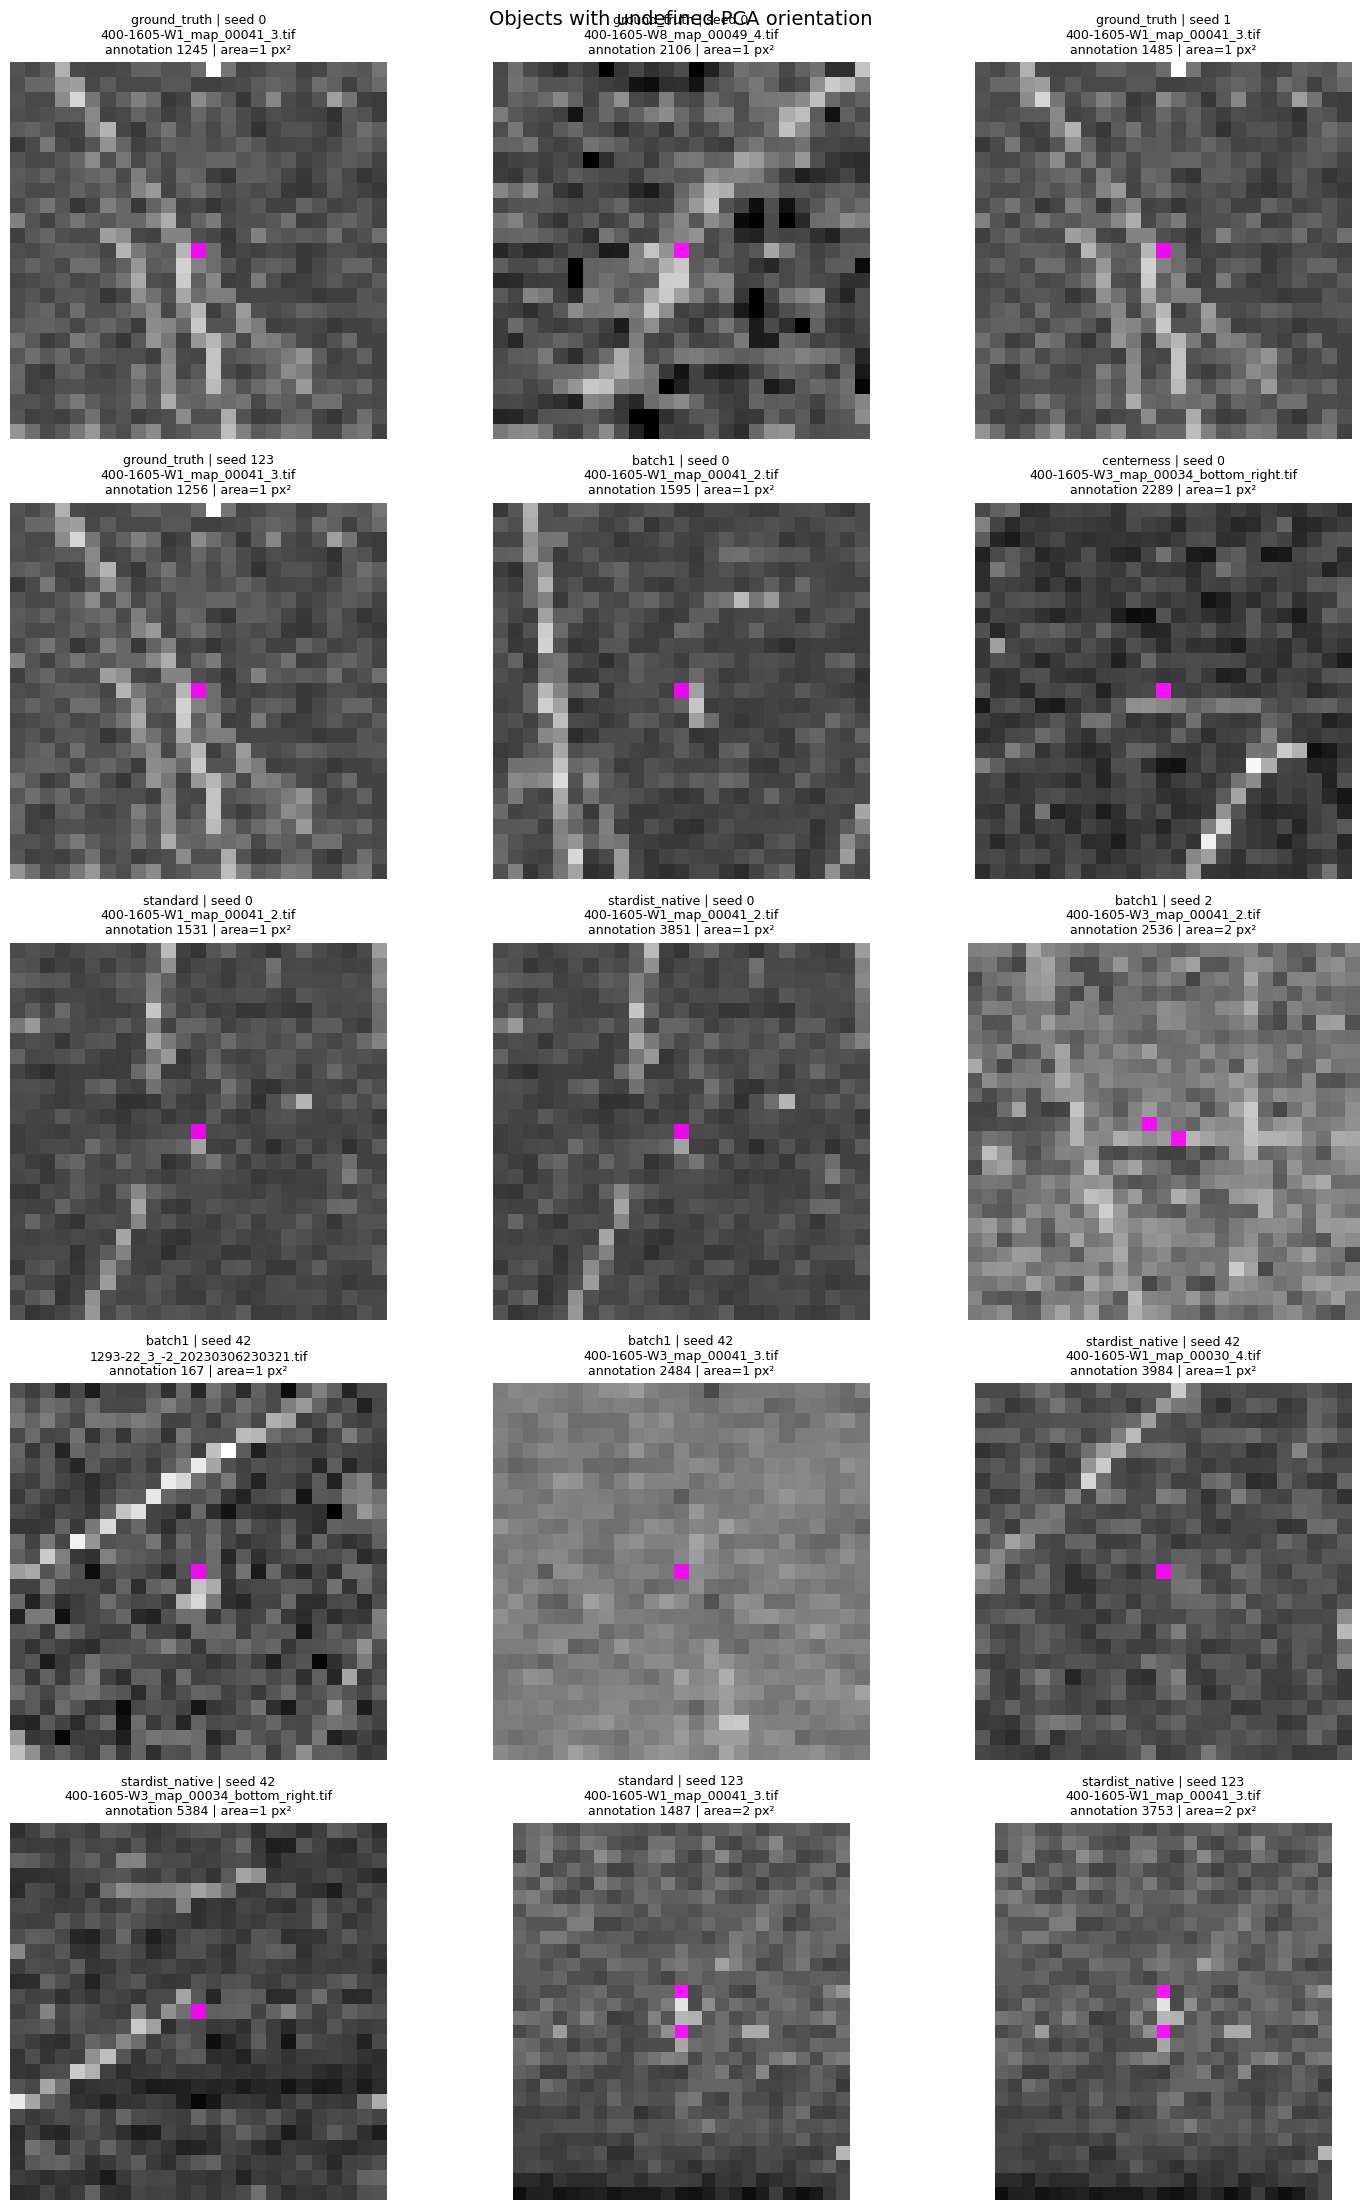

In [13]:
import matplotlib.pyplot as plt


columns = 3
rows = int(
    np.ceil(
        len(undefined_objects)
        / columns
    )
)

figure, axes = plt.subplots(
    rows,
    columns,
    figsize=(
        15,
        4.5 * rows,
    ),
)

axes = np.asarray(
    axes
).reshape(-1)


for axis, item in zip(
    axes,
    undefined_objects,
):
    image = item["image"]
    mask = item["mask"]

    y_coordinates, x_coordinates = (
        np.where(mask)
    )

    padding = 12

    y_min = max(
        0,
        int(y_coordinates.min())
        - padding,
    )

    y_max = min(
        mask.shape[0],
        int(y_coordinates.max())
        + padding
        + 1,
    )

    x_min = max(
        0,
        int(x_coordinates.min())
        - padding,
    )

    x_max = min(
        mask.shape[1],
        int(x_coordinates.max())
        + padding
        + 1,
    )


    image_crop = image[
        y_min:y_max,
        x_min:x_max,
    ]

    mask_crop = mask[
        y_min:y_max,
        x_min:x_max,
    ]


    axis.imshow(
        image_crop,
        cmap="gray",
    )

    overlay = np.zeros(
        (
            mask_crop.shape[0],
            mask_crop.shape[1],
            4,
        ),
        dtype=float,
    )

    overlay[
        mask_crop
    ] = [
        1.0,
        0.0,
        1.0,
        0.9,
    ]

    axis.imshow(
        overlay,
        interpolation="nearest",
    )

    axis.set_title(
        f"{item['family']} | "
        f"seed {item['seed']}\n"
        f"{item['filename']}\n"
        f"annotation {item['annotation_id']} | "
        f"area={item['area_pixels2']} px²",
        fontsize=9,
    )

    axis.axis("off")


for axis in axes[
    len(undefined_objects):
]:
    axis.axis("off")


figure.suptitle(
    "Objects with undefined PCA orientation",
    fontsize=14,
)

figure.tight_layout()
plt.show()

## Exclude degenerate objects from morphology comparisons
Objects without a finite PCA orientation were visually
confirmed to consist of one pixel or disconnected single pixels.
They are excluded from all object-level morphology distributions.

In [14]:
clean_gt_object_tables = {}

for seed in SEEDS:
    table = (
        gt_tables[seed]["object"]
        .copy()
    )

    valid_object_mask = np.isfinite(
        pd.to_numeric(
            table["orientation_angle"],
            errors="coerce",
        )
    )

    clean_gt_object_tables[seed] = (
        table.loc[
            valid_object_mask
        ].copy()
    )


clean_prediction_object_tables = {}

for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])

    table = (
        prediction_tables[
            (family, seed)
        ]["object"]
        .copy()
    )

    valid_object_mask = np.isfinite(
        pd.to_numeric(
            table["orientation_angle"],
            errors="coerce",
        )
    )

    clean_prediction_object_tables[
        (family, seed)
    ] = (
        table.loc[
            valid_object_mask
        ].copy()
    )

In [15]:
gt_before = sum(
    len(
        gt_tables[seed]["object"]
    )
    for seed in SEEDS
)

gt_after = sum(
    len(
        clean_gt_object_tables[seed]
    )
    for seed in SEEDS
)

prediction_before = sum(
    len(
        prediction_tables[
            (
                row["family"],
                int(row["seed"]),
            )
        ]["object"]
    )
    for _, row in run_manifest_df.iterrows()
)

prediction_after = sum(
    len(
        clean_prediction_object_tables[
            (
                row["family"],
                int(row["seed"]),
            )
        ]
    )
    for _, row in run_manifest_df.iterrows()
)


print(
    "GT objects:",
    gt_before,
    "→",
    gt_after,
    "| excluded:",
    gt_before - gt_after,
)

print(
    "Prediction objects:",
    prediction_before,
    "→",
    prediction_after,
    "| excluded:",
    prediction_before
    - prediction_after,
)


if gt_before - gt_after != 4:
    raise RuntimeError(
        "Expected exactly 4 excluded GT objects."
    )

if prediction_before - prediction_after != 11:
    raise RuntimeError(
        "Expected exactly 11 excluded "
        "prediction objects."
    )


print()
print(
    "PASS: all 15 visually confirmed "
    "degenerate objects were excluded."
)

GT objects: 10612 → 10608 | excluded: 4
Prediction objects: 128488 → 128477 | excluded: 11

PASS: all 15 visually confirmed degenerate objects were excluded.


## Shared settings for distribution comparisons

In [16]:
from scipy.spatial.distance import (
    jensenshannon,
)
from scipy.stats import (
    wasserstein_distance,
)


JSD_BINS = 60
JSD_BASE = 2


LINEAR_FEATURE_LEVELS = {
    "length_um": "object",
    "tree_length_um": "object",
    "line_density_mean": "image",
}
def finite_values(values):
    values = np.asarray(
        pd.to_numeric(
            values,
            errors="coerce",
        ),
        dtype=float,
    )

    return values[
        np.isfinite(values)
    ]


def make_bin_edges(
    values,
    *,
    bins=JSD_BINS,
):
    values = finite_values(
        values
    )

    if len(values) == 0:
        raise ValueError(
            "Cannot build histogram edges "
            "from an empty collection."
        )

    minimum = float(
        values.min()
    )

    maximum = float(
        values.max()
    )

    if minimum == maximum:
        padding = (
            abs(minimum) * 0.01
            if minimum != 0
            else 0.5
        )

        minimum -= padding
        maximum += padding

    return np.linspace(
        minimum,
        maximum,
        bins + 1,
    )

## Create one global histogram definition per feature

In [17]:
global_feature_values = {
    feature: []
    for feature in LINEAR_FEATURE_LEVELS
}


# Include every GT split once.
for seed in SEEDS:
    global_feature_values[
        "length_um"
    ].append(
        finite_values(
            clean_gt_object_tables[
                seed
            ]["length_um"]
        )
    )

    global_feature_values[
        "tree_length_um"
    ].append(
        finite_values(
            clean_gt_object_tables[
                seed
            ]["tree_length_um"]
        )
    )

    global_feature_values[
        "line_density_mean"
    ].append(
        finite_values(
            gt_tables[
                seed
            ]["image"][
                "line_density_mean"
            ]
        )
    )


# Include all 40 prediction runs.
for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])

    prediction_object_df = (
        clean_prediction_object_tables[
            (family, seed)
        ]
    )

    prediction_image_df = (
        prediction_tables[
            (family, seed)
        ]["image"]
    )

    global_feature_values[
        "length_um"
    ].append(
        finite_values(
            prediction_object_df[
                "length_um"
            ]
        )
    )

    global_feature_values[
        "tree_length_um"
    ].append(
        finite_values(
            prediction_object_df[
                "tree_length_um"
            ]
        )
    )

    global_feature_values[
        "line_density_mean"
    ].append(
        finite_values(
            prediction_image_df[
                "line_density_mean"
            ]
        )
    )


global_bin_edges = {}


for feature, arrays in (
    global_feature_values.items()
):
    combined_values = np.concatenate(
        arrays
    )

    global_bin_edges[feature] = (
        make_bin_edges(
            combined_values,
            bins=JSD_BINS,
        )
    )


global_bin_summary_df = pd.DataFrame(
    [
        {
            "feature": feature,
            "bins": (
                len(edges) - 1
            ),
            "minimum": float(
                edges[0]
            ),
            "maximum": float(
                edges[-1]
            ),
            "bin_width": float(
                edges[1] - edges[0]
            ),
            "jsd_base": JSD_BASE,
        }
        for feature, edges
        in global_bin_edges.items()
    ]
)


display(global_bin_summary_df)

,feature,bins,minimum,maximum,bin_width,jsd_base
0,length_um,60,0.019531,5.376884,0.089289,2
1,tree_length_um,60,0.000000,5.344524,0.089075,2
2,line_density_mean,60,0.000000,39.328125,0.655469,2


## Calculate Wasserstein and Jensen–Shannon distances

In [18]:
def linear_distribution_distances(
    gt_values,
    prediction_values,
    *,
    bin_edges,
):
    gt_values = finite_values(
        gt_values
    )

    prediction_values = finite_values(
        prediction_values
    )

    if len(gt_values) == 0:
        return {
            "wasserstein_distance": np.nan,
            "jensen_shannon_distance": np.nan,
            "n_gt_used": 0,
            "n_pred_used": len(
                prediction_values
            ),
            "status": "empty_ground_truth",
        }

    if len(prediction_values) == 0:
        return {
            "wasserstein_distance": np.nan,
            "jensen_shannon_distance": np.nan,
            "n_gt_used": len(gt_values),
            "n_pred_used": 0,
            "status": "empty_prediction",
        }

    gt_histogram, _ = np.histogram(
        gt_values,
        bins=bin_edges,
    )

    prediction_histogram, _ = np.histogram(
        prediction_values,
        bins=bin_edges,
    )

    return {
        "wasserstein_distance": float(
            wasserstein_distance(
                gt_values,
                prediction_values,
            )
        ),
        "jensen_shannon_distance": float(
            jensenshannon(
                gt_histogram,
                prediction_histogram,
                base=JSD_BASE,
            )
        ),
        "n_gt_used": len(gt_values),
        "n_pred_used": len(
            prediction_values
        ),
        "status": "ok",
    }

## Pooled split-level linear comparisons

In [19]:
pooled_linear_rows = []


for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])
    run = manifest_row["run"]

    gt_object_df = (
        clean_gt_object_tables[seed]
    )

    prediction_object_df = (
        clean_prediction_object_tables[
            (family, seed)
        ]
    )

    gt_image_df = (
        gt_tables[seed]["image"]
    )

    prediction_image_df = (
        prediction_tables[
            (family, seed)
        ]["image"]
    )


    feature_sources = {
        "length_um": (
            gt_object_df["length_um"],
            prediction_object_df[
                "length_um"
            ],
            "object",
        ),
        "tree_length_um": (
            gt_object_df[
                "tree_length_um"
            ],
            prediction_object_df[
                "tree_length_um"
            ],
            "object",
        ),
        "line_density_mean": (
            gt_image_df[
                "line_density_mean"
            ],
            prediction_image_df[
                "line_density_mean"
            ],
            "image",
        ),
    }


    for feature, (
        gt_values,
        prediction_values,
        feature_level,
    ) in feature_sources.items():
        result = (
            linear_distribution_distances(
                gt_values,
                prediction_values,
                bin_edges=(
                    global_bin_edges[
                        feature
                    ]
                ),
            )
        )

        pooled_linear_rows.append(
            {
                "family": family,
                "seed": seed,
                "run": run,
                "feature": feature,
                "feature_level": (
                    feature_level
                ),
                "aggregation": (
                    "pooled_split"
                ),
                "histogram_bins": (
                    JSD_BINS
                ),
                "jsd_base": JSD_BASE,
                **result,
            }
        )


pooled_linear_results_df = (
    pd.DataFrame(
        pooled_linear_rows
    )
)


print(
    "Pooled comparisons:",
    len(
        pooled_linear_results_df
    ),
)

print(
    pooled_linear_results_df[
        "status"
    ].value_counts()
)

display(
    pooled_linear_results_df.head()
)

Pooled comparisons: 120
status
ok    120
Name: count, dtype: int64


,family,seed,run,feature,feature_level,aggregation,histogram_bins,jsd_base,wasserstein_distance,jensen_shannon_distance,n_gt_used,n_pred_used,status
0,batch1,0,batch1_seed_0_optimized_test_no_smoothing,length_um,object,pooled_split,60,2,0.191071,0.271945,2176,2999,ok
1,batch1,0,batch1_seed_0_optimized_test_no_smoothing,tree_length_um,object,pooled_split,60,2,0.167697,0.234069,2176,2999,ok
2,batch1,0,batch1_seed_0_optimized_test_no_smoothing,line_density_mean,image,pooled_split,60,2,0.652083,0.490767,30,30,ok
3,wormswin,0,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,length_um,object,pooled_split,60,2,0.209596,0.261045,2176,1561,ok
4,wormswin,0,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,tree_length_um,object,pooled_split,60,2,0.192342,0.227340,2176,1561,ok


## Per-image linear comparisons
Per-image Wasserstein/JSD comparisons are calculated for
object-level length distributions. `line_density_mean` has
only one value per image, so it is evaluated only as a pooled
split-level distribution.

In [20]:
per_image_linear_rows = []


for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])
    run = manifest_row["run"]

    gt_object_df = (
        clean_gt_object_tables[seed]
    )

    prediction_object_df = (
        clean_prediction_object_tables[
            (family, seed)
        ]
    )

    image_keys = sorted(
        gt_tables[seed]["image"][
            "image_key"
        ].unique()
    )


    for feature in [
        "length_um",
        "tree_length_um",
    ]:
        for current_image_key in image_keys:
            gt_values = (
                gt_object_df.loc[
                    gt_object_df[
                        "image_key"
                    ].eq(current_image_key),
                    feature,
                ]
            )

            prediction_values = (
                prediction_object_df.loc[
                    prediction_object_df[
                        "image_key"
                    ].eq(current_image_key),
                    feature,
                ]
            )

            result = (
                linear_distribution_distances(
                    gt_values,
                    prediction_values,
                    bin_edges=(
                        global_bin_edges[
                            feature
                        ]
                    ),
                )
            )

            per_image_linear_rows.append(
                {
                    "family": family,
                    "seed": seed,
                    "run": run,
                    "image_key": (
                        current_image_key
                    ),
                    "feature": feature,
                    "feature_level": "object",
                    "aggregation": "per_image",
                    "histogram_bins": (
                        JSD_BINS
                    ),
                    "jsd_base": JSD_BASE,
                    **result,
                }
            )


per_image_linear_results_df = (
    pd.DataFrame(
        per_image_linear_rows
    )
)


print(
    "Per-image comparisons:",
    len(
        per_image_linear_results_df
    ),
)

print()
print(
    per_image_linear_results_df[
        "status"
    ].value_counts()
)

Per-image comparisons: 2400

status
ok                  2398
empty_prediction       2
Name: count, dtype: int64


In [21]:
empty_linear_comparisons_df = (
    per_image_linear_results_df.loc[
        per_image_linear_results_df[
            "status"
        ].ne("ok")
    ].copy()
)


print(
    "Empty per-image comparisons:",
    len(
        empty_linear_comparisons_df
    ),
)

display(
    empty_linear_comparisons_df
)

Empty per-image comparisons: 2


,family,seed,run,image_key,feature,feature_level,aggregation,histogram_bins,jsd_base,wasserstein_distance,jensen_shannon_distance,n_gt_used,n_pred_used,status
1040,wormswin,2,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,400-1605-w3_map_00041_2,length_um,object,per_image,60,2,NaN,NaN,59,0,empty_prediction
1070,wormswin,2,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,400-1605-w3_map_00041_2,tree_length_um,object,per_image,60,2,NaN,NaN,59,0,empty_prediction


## Inspect the WormSwin image with no extracted predictions

In [22]:
WORMSWIN_EMPTY_RUN = (
    "cnt_WormSwin_trial_1_epochs_100_"
    "lr_0.00025_unfreeze_2_dataset_"
    "stratified_seed_2_split_2"
)

WORMSWIN_EMPTY_IMAGE_KEY = (
    "400-1605-w3_map_00041_2"
)

wormswin_run_root = (
    RUNS_ROOT
    / WORMSWIN_EMPTY_RUN
)

wormswin_poly_path = (
    wormswin_run_root
    / "inference"
    / "predicted_annotations_poly.json"
)

wormswin_rle_path = (
    wormswin_run_root
    / "inference"
    / "predicted_annotations_rle.json"
)


for path in [
    wormswin_poly_path,
    wormswin_rle_path,
]:
    if not path.is_file():
        raise FileNotFoundError(path)


print(
    "Feature extraction source:",
    source_json_paths[
        ("wormswin", 2)
    ],
)

print(
    "Polygon JSON:",
    wormswin_poly_path,
)

print(
    "RLE JSON:",
    wormswin_rle_path,
)
# %%
WORMSWIN_EMPTY_RUN = (
    "cnt_WormSwin_trial_1_epochs_100_"
    "lr_0.00025_unfreeze_2_dataset_"
    "stratified_seed_2_split_2"
)

WORMSWIN_EMPTY_IMAGE_KEY = (
    "400-1605-w3_map_00041_2"
)

wormswin_run_root = (
    RUNS_ROOT
    / WORMSWIN_EMPTY_RUN
)

wormswin_poly_path = (
    wormswin_run_root
    / "inference"
    / "predicted_annotations_poly.json"
)

wormswin_rle_path = (
    wormswin_run_root
    / "inference"
    / "predicted_annotations_rle.json"
)


for path in [
    wormswin_poly_path,
    wormswin_rle_path,
]:
    if not path.is_file():
        raise FileNotFoundError(path)


print(
    "Feature extraction source:",
    source_json_paths[
        ("wormswin", 2)
    ],
)

print(
    "Polygon JSON:",
    wormswin_poly_path,
)

print(
    "RLE JSON:",
    wormswin_rle_path,
)
# %%
wormswin_poly_coco = load_coco_json(
    wormswin_poly_path
)

wormswin_rle_coco = load_coco_json(
    wormswin_rle_path
)


def find_image_and_annotations(
    coco_data,
    target_image_key,
):
    matching_images = [
        image
        for image in coco_data["images"]
        if image_key(
            image["file_name"]
        )
        == target_image_key
    ]

    if len(matching_images) != 1:
        raise RuntimeError(
            f"Expected one image record for "
            f"{target_image_key}; found "
            f"{len(matching_images)}."
        )

    image_record = matching_images[0]

    annotations = [
        annotation
        for annotation
        in coco_data["annotations"]
        if int(annotation["image_id"])
        == int(image_record["id"])
    ]

    return (
        image_record,
        annotations,
    )


(
    wormswin_poly_image,
    wormswin_poly_annotations,
) = find_image_and_annotations(
    wormswin_poly_coco,
    WORMSWIN_EMPTY_IMAGE_KEY,
)

(
    wormswin_rle_image,
    wormswin_rle_annotations,
) = find_image_and_annotations(
    wormswin_rle_coco,
    WORMSWIN_EMPTY_IMAGE_KEY,
)


print(
    "Polygon annotations:",
    len(wormswin_poly_annotations),
)

print(
    "RLE annotations:",
    len(wormswin_rle_annotations),
)
# %%
wormswin_source_path = (
    source_json_paths[
        ("wormswin", 2)
    ]
)

wormswin_prediction_paths = {
    "feature_extraction_source": (
        wormswin_source_path
    ),
    "polygon": wormswin_poly_path,
    "rle": wormswin_rle_path,
}


image_presence_rows = []


for representation, json_path in (
    wormswin_prediction_paths.items()
):
    coco_data = load_coco_json(
        json_path
    )

    matching_images = [
        image
        for image in coco_data["images"]
        if image_key(
            image["file_name"]
        )
        == WORMSWIN_EMPTY_IMAGE_KEY
    ]

    if len(matching_images) != 1:
        raise RuntimeError(
            f"{representation}: expected one "
            f"image record; found "
            f"{len(matching_images)}."
        )

    image_record = matching_images[0]

    image_id = int(
        image_record["id"]
    )

    matching_annotations = [
        annotation
        for annotation
        in coco_data["annotations"]
        if int(annotation["image_id"])
        == image_id
    ]

    image_presence_rows.append(
        {
            "representation": representation,
            "json_path": json_path,
            "image_id": image_id,
            "file_name": (
                image_record["file_name"]
            ),
            "annotation_count": len(
                matching_annotations
            ),
        }
    )


wormswin_empty_image_check_df = (
    pd.DataFrame(
        image_presence_rows
    )
)

display(
    wormswin_empty_image_check_df
)

Feature extraction source: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unfreeze_2_dataset_stratified_seed_2_split_2\inference\predicted_annotations_rle_opencv.json
Polygon JSON: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unfreeze_2_dataset_stratified_seed_2_split_2\inference\predicted_annotations_poly.json
RLE JSON: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unfreeze_2_dataset_stratified_seed_2_split_2\inference\predicted_annotations_rle.json
Feature extraction source: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unfreeze_2_dataset_stratified_seed_2_split_2\inference\predicted_annotations_rle_opencv.json
Polygon JSON: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\cnt_WormSwin_trial_1_epochs_100_

,representation,json_path,image_id,file_name,annotation_count
0,feature_extraction_source,C:\Users\abd93000\PycharmProjects\cnt_project_...,21,400-1605-W3_map_00041_2.tif,0
1,polygon,c:\Users\abd93000\PycharmProjects\cnt_project_...,21,400-1605-W3_map_00041_2.tif,0
2,rle,c:\Users\abd93000\PycharmProjects\cnt_project_...,21,400-1605-W3_map_00041_2.tif,0


## Prediction coverage by run
Distribution distances are reported separately from images
where a model produced no eligible objects.

In [23]:
coverage_rows = []


for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])
    run = manifest_row["run"]

    gt_image_keys = sorted(
        gt_tables[seed]["image"][
            "image_key"
        ].unique()
    )

    prediction_object_df = (
        clean_prediction_object_tables[
            (family, seed)
        ]
    )

    prediction_counts = (
        prediction_object_df[
            "image_key"
        ]
        .value_counts()
        .reindex(
            gt_image_keys,
            fill_value=0,
        )
    )

    empty_image_keys = (
        prediction_counts.loc[
            prediction_counts.eq(0)
        ].index.tolist()
    )

    valid_image_count = int(
        prediction_counts.gt(0).sum()
    )

    total_image_count = len(
        gt_image_keys
    )

    coverage_rows.append(
        {
            "family": family,
            "seed": seed,
            "run": run,
            "total_images": (
                total_image_count
            ),
            "images_with_predictions": (
                valid_image_count
            ),
            "empty_prediction_images": (
                len(empty_image_keys)
            ),
            "prediction_image_coverage": (
                valid_image_count
                / total_image_count
            ),
            "empty_image_keys": (
                ";".join(empty_image_keys)
            ),
        }
    )


prediction_coverage_df = pd.DataFrame(
    coverage_rows
)


display(
    prediction_coverage_df.loc[
        prediction_coverage_df[
            "empty_prediction_images"
        ].gt(0)
    ]
)
# %%
runs_with_empty_predictions = (
    prediction_coverage_df.loc[
        prediction_coverage_df[
            "empty_prediction_images"
        ].gt(0)
    ]
)


if len(runs_with_empty_predictions) != 1:
    raise RuntimeError(
        "Expected exactly one run with an "
        "empty prediction image."
    )


empty_run = (
    runs_with_empty_predictions.iloc[0]
)


if not (
    empty_run["family"] == "wormswin"
    and int(empty_run["seed"]) == 2
    and int(
        empty_run[
            "empty_prediction_images"
        ]
    ) == 1
):
    raise RuntimeError(
        "Unexpected prediction-coverage result."
    )


print(
    "PASS: prediction coverage was recorded "
    "separately from distribution distances."
)

,family,seed,run,total_images,images_with_predictions,empty_prediction_images,prediction_image_coverage,empty_image_keys
17,wormswin,2,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,30,29,1,0.966667,400-1605-w3_map_00041_2


PASS: prediction coverage was recorded separately from distribution distances.


## Summarize per-image linear distances

In [24]:
per_image_linear_summary_df = (
    per_image_linear_results_df
    .groupby(
        [
            "family",
            "seed",
            "run",
            "feature",
        ],
        as_index=False,
    )
    .agg(
        mean_wasserstein_distance=(
            "wasserstein_distance",
            "mean",
        ),
        std_wasserstein_distance=(
            "wasserstein_distance",
            "std",
        ),
        mean_jensen_shannon_distance=(
            "jensen_shannon_distance",
            "mean",
        ),
        std_jensen_shannon_distance=(
            "jensen_shannon_distance",
            "std",
        ),
        valid_image_count=(
            "status",
            lambda values: int(
                values.eq("ok").sum()
            ),
        ),
        empty_prediction_image_count=(
            "status",
            lambda values: int(
                values.eq(
                    "empty_prediction"
                ).sum()
            ),
        ),
        total_image_count=(
            "image_key",
            "nunique",
        ),
    )
)


per_image_linear_summary_df[
    "valid_image_fraction"
] = (
    per_image_linear_summary_df[
        "valid_image_count"
    ]
    / per_image_linear_summary_df[
        "total_image_count"
    ]
)


print(
    "Per-image summary rows:",
    len(
        per_image_linear_summary_df
    ),
)

display(
    per_image_linear_summary_df.loc[
        per_image_linear_summary_df[
            "empty_prediction_image_count"
        ].gt(0)
    ]
)

Per-image summary rows: 80


,family,seed,run,feature,mean_wasserstein_distance,std_wasserstein_distance,mean_jensen_shannon_distance,std_jensen_shannon_distance,valid_image_count,empty_prediction_image_count,total_image_count,valid_image_fraction
74,wormswin,2,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,length_um,0.236315,0.142622,0.494577,0.197349,29,1,30,0.966667
75,wormswin,2,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,tree_length_um,0.231578,0.133494,0.497868,0.164534,29,1,30,0.966667


## Axial orientation distribution comparison
CNT orientation is axial and has a period of 180 degrees.
Therefore, -90 and +90 degrees represent the same axis.
Orientation comparisons use:
- 60 fixed bins between -90 and +90 degrees;
- circular Wasserstein distance;
- circularly smoothed Jensen–Shannon distance;
- base 2 for compatibility with the legacy implementation.

In [25]:
from scipy.ndimage import (
    gaussian_filter1d,
)


ORIENTATION_PERIOD_DEG = 180.0
ORIENTATION_BIN_COUNT = 60
ORIENTATION_SMOOTHING_SIGMA_BINS = 1.0

ORIENTATION_BIN_EDGES = np.linspace(
    -90.0,
    90.0,
    ORIENTATION_BIN_COUNT + 1,
)

ORIENTATION_BIN_WIDTH_DEG = float(
    ORIENTATION_BIN_EDGES[1]
    - ORIENTATION_BIN_EDGES[0]
)


print(
    "Orientation bins:",
    ORIENTATION_BIN_COUNT,
)

print(
    "Orientation bin width:",
    ORIENTATION_BIN_WIDTH_DEG,
    "degrees",
)

print(
    "Circular smoothing sigma:",
    ORIENTATION_SMOOTHING_SIGMA_BINS,
    "bin",
)

Orientation bins: 60
Orientation bin width: 3.0 degrees
Circular smoothing sigma: 1.0 bin


In [26]:
def normalize_axial_angles(
    values,
):
    values = finite_values(
        values
    )

    # Map any equivalent axial representation
    # into [-90, 90).
    return (
        (
            values + 90.0
        )
        % ORIENTATION_PERIOD_DEG
    ) - 90.0

# Build circular histograms
def circular_orientation_histogram(
    values,
    *,
    smooth=False,
):
    values = normalize_axial_angles(
        values
    )

    histogram, _ = np.histogram(
        values,
        bins=ORIENTATION_BIN_EDGES,
    )

    histogram = histogram.astype(
        float
    )

    if smooth:
        histogram = gaussian_filter1d(
            histogram,
            sigma=(
                ORIENTATION_SMOOTHING_SIGMA_BINS
            ),
            mode="wrap",
        )

    histogram_sum = float(
        histogram.sum()
    )

    if histogram_sum > 0:
        histogram /= histogram_sum

    return histogram

def circular_wasserstein_distance_deg(
    first_histogram,
    second_histogram,
):
    first_histogram = np.asarray(
        first_histogram,
        dtype=float,
    )

    second_histogram = np.asarray(
        second_histogram,
        dtype=float,
    )

    if (
        first_histogram.shape
        != second_histogram.shape
    ):
        raise ValueError(
            "Circular histograms must have "
            "the same shape."
        )

    difference = (
        first_histogram
        - second_histogram
    )

    cumulative_difference = np.cumsum(
        difference
    )

    optimal_offset = np.median(
        cumulative_difference
    )

    return float(
        ORIENTATION_BIN_WIDTH_DEG
        * np.sum(
            np.abs(
                cumulative_difference
                - optimal_offset
            )
        )
    )

def axial_distribution_distances(
    gt_values,
    prediction_values,
):
    gt_values = normalize_axial_angles(
        gt_values
    )

    prediction_values = (
        normalize_axial_angles(
            prediction_values
        )
    )

    if len(gt_values) == 0:
        return {
            "circular_wasserstein_distance_deg": (
                np.nan
            ),
            "jensen_shannon_distance": np.nan,
            "n_gt_used": 0,
            "n_pred_used": len(
                prediction_values
            ),
            "status": "empty_ground_truth",
        }

    if len(prediction_values) == 0:
        return {
            "circular_wasserstein_distance_deg": (
                np.nan
            ),
            "jensen_shannon_distance": np.nan,
            "n_gt_used": len(gt_values),
            "n_pred_used": 0,
            "status": "empty_prediction",
        }


    gt_histogram = (
        circular_orientation_histogram(
            gt_values,
            smooth=False,
        )
    )

    prediction_histogram = (
        circular_orientation_histogram(
            prediction_values,
            smooth=False,
        )
    )


    gt_smoothed_histogram = (
        circular_orientation_histogram(
            gt_values,
            smooth=True,
        )
    )

    prediction_smoothed_histogram = (
        circular_orientation_histogram(
            prediction_values,
            smooth=True,
        )
    )


    return {
        "circular_wasserstein_distance_deg": (
            circular_wasserstein_distance_deg(
                gt_histogram,
                prediction_histogram,
            )
        ),
        "jensen_shannon_distance": float(
            jensenshannon(
                gt_smoothed_histogram,
                prediction_smoothed_histogram,
                base=JSD_BASE,
            )
        ),
        "n_gt_used": len(gt_values),
        "n_pred_used": len(
            prediction_values
        ),
        "status": "ok",
    }

## Pooled split-level orientation comparison

In [27]:
pooled_orientation_rows = []


for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])
    run = manifest_row["run"]

    gt_object_df = (
        clean_gt_object_tables[seed]
    )

    prediction_object_df = (
        clean_prediction_object_tables[
            (family, seed)
        ]
    )

    result = axial_distribution_distances(
        gt_object_df[
            "orientation_angle"
        ],
        prediction_object_df[
            "orientation_angle"
        ],
    )

    pooled_orientation_rows.append(
        {
            "family": family,
            "seed": seed,
            "run": run,
            "feature": "orientation_angle",
            "feature_level": "object",
            "aggregation": "pooled_split",
            "orientation_period_deg": (
                ORIENTATION_PERIOD_DEG
            ),
            "histogram_bins": (
                ORIENTATION_BIN_COUNT
            ),
            "histogram_bin_width_deg": (
                ORIENTATION_BIN_WIDTH_DEG
            ),
            "smoothing_sigma_bins": (
                ORIENTATION_SMOOTHING_SIGMA_BINS
            ),
            "jsd_base": JSD_BASE,
            **result,
        }
    )


pooled_orientation_results_df = (
    pd.DataFrame(
        pooled_orientation_rows
    )
)


print(
    "Pooled orientation comparisons:",
    len(
        pooled_orientation_results_df
    ),
)

print()
print(
    pooled_orientation_results_df[
        "status"
    ].value_counts()
)

display(
    pooled_orientation_results_df.head()
)

Pooled orientation comparisons: 40

status
ok    40
Name: count, dtype: int64


,family,seed,run,feature,feature_level,aggregation,orientation_period_deg,histogram_bins,histogram_bin_width_deg,smoothing_sigma_bins,jsd_base,circular_wasserstein_distance_deg,jensen_shannon_distance,n_gt_used,n_pred_used,status
0,batch1,0,batch1_seed_0_optimized_test_no_smoothing,orientation_angle,object,pooled_split,180.0,60,3.0,1.0,2,0.812346,0.039888,2176,2999,ok
1,wormswin,0,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,orientation_angle,object,pooled_split,180.0,60,3.0,1.0,2,2.502504,0.070747,2176,1561,ok
2,cpsam_v2,0,cpsam_v2_stratified_seed_0_100epochs_best_vali...,orientation_angle,object,pooled_split,180.0,60,3.0,1.0,2,0.865574,0.039718,2176,2164,ok
3,detectron2,0,detectron2_trial_1__epochs_10000_lr_0.0001_unf...,orientation_angle,object,pooled_split,180.0,60,3.0,1.0,2,1.849865,0.071958,2176,2420,ok
4,centerness,0,nanovision_centerness_stratified_seed_0_fresh_...,orientation_angle,object,pooled_split,180.0,60,3.0,1.0,2,1.378168,0.046858,2176,2982,ok


## Per-image orientation comparison

In [28]:
per_image_orientation_rows = []


for _, manifest_row in (
    run_manifest_df.iterrows()
):
    family = manifest_row["family"]
    seed = int(manifest_row["seed"])
    run = manifest_row["run"]

    gt_object_df = (
        clean_gt_object_tables[seed]
    )

    prediction_object_df = (
        clean_prediction_object_tables[
            (family, seed)
        ]
    )

    image_keys = sorted(
        gt_tables[seed]["image"][
            "image_key"
        ].unique()
    )


    for current_image_key in image_keys:
        gt_values = (
            gt_object_df.loc[
                gt_object_df[
                    "image_key"
                ].eq(current_image_key),
                "orientation_angle",
            ]
        )

        prediction_values = (
            prediction_object_df.loc[
                prediction_object_df[
                    "image_key"
                ].eq(current_image_key),
                "orientation_angle",
            ]
        )

        result = axial_distribution_distances(
            gt_values,
            prediction_values,
        )

        per_image_orientation_rows.append(
            {
                "family": family,
                "seed": seed,
                "run": run,
                "image_key": current_image_key,
                "feature": "orientation_angle",
                "feature_level": "object",
                "aggregation": "per_image",
                "orientation_period_deg": (
                    ORIENTATION_PERIOD_DEG
                ),
                "histogram_bins": (
                    ORIENTATION_BIN_COUNT
                ),
                "histogram_bin_width_deg": (
                    ORIENTATION_BIN_WIDTH_DEG
                ),
                "smoothing_sigma_bins": (
                    ORIENTATION_SMOOTHING_SIGMA_BINS
                ),
                "jsd_base": JSD_BASE,
                **result,
            }
        )


per_image_orientation_results_df = (
    pd.DataFrame(
        per_image_orientation_rows
    )
)


print(
    "Per-image orientation comparisons:",
    len(
        per_image_orientation_results_df
    ),
)

print()
print(
    per_image_orientation_results_df[
        "status"
    ].value_counts()
)

Per-image orientation comparisons: 1200

status
ok                  1199
empty_prediction       1
Name: count, dtype: int64


In [29]:
per_image_orientation_summary_df = (
    per_image_orientation_results_df
    .groupby(
        [
            "family",
            "seed",
            "run",
            "feature",
        ],
        as_index=False,
    )
    .agg(
        mean_circular_wasserstein_distance_deg=(
            "circular_wasserstein_distance_deg",
            "mean",
        ),
        std_circular_wasserstein_distance_deg=(
            "circular_wasserstein_distance_deg",
            "std",
        ),
        mean_jensen_shannon_distance=(
            "jensen_shannon_distance",
            "mean",
        ),
        std_jensen_shannon_distance=(
            "jensen_shannon_distance",
            "std",
        ),
        valid_image_count=(
            "status",
            lambda values: int(
                values.eq("ok").sum()
            ),
        ),
        empty_prediction_image_count=(
            "status",
            lambda values: int(
                values.eq(
                    "empty_prediction"
                ).sum()
            ),
        ),
        total_image_count=(
            "image_key",
            "nunique",
        ),
    )
)


per_image_orientation_summary_df[
    "valid_image_fraction"
] = (
    per_image_orientation_summary_df[
        "valid_image_count"
    ]
    / per_image_orientation_summary_df[
        "total_image_count"
    ]
)


print(
    "Orientation summary rows:",
    len(
        per_image_orientation_summary_df
    ),
)

display(
    per_image_orientation_summary_df.loc[
        per_image_orientation_summary_df[
            "empty_prediction_image_count"
        ].gt(0)
    ]
)

Orientation summary rows: 40


,family,seed,run,feature,mean_circular_wasserstein_distance_deg,std_circular_wasserstein_distance_deg,mean_jensen_shannon_distance,std_jensen_shannon_distance,valid_image_count,empty_prediction_image_count,total_image_count,valid_image_fraction
37,wormswin,2,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,orientation_angle,7.914564,4.973959,0.316825,0.134596,29,1,30,0.966667


## Combine pooled results

In [30]:
pooled_linear_table = (
    pooled_linear_results_df[
        [
            "family",
            "seed",
            "run",
            "feature",
            "wasserstein_distance",
            "jensen_shannon_distance",
            "status",
        ]
    ]
    .copy()
)

pooled_linear_table[
    "wasserstein_type"
] = "linear"


pooled_orientation_table = (
    pooled_orientation_results_df[
        [
            "family",
            "seed",
            "run",
            "feature",
            (
                "circular_wasserstein_"
                "distance_deg"
            ),
            "jensen_shannon_distance",
            "status",
        ]
    ]
    .rename(
        columns={
            (
                "circular_wasserstein_"
                "distance_deg"
            ): "wasserstein_distance",
        }
    )
    .copy()
)

pooled_orientation_table[
    "wasserstein_type"
] = "circular_axial"


pooled_results_df = pd.concat(
    [
        pooled_linear_table,
        pooled_orientation_table,
    ],
    ignore_index=True,
)


if len(pooled_results_df) != 160:
    raise RuntimeError(
        "Expected 40 runs × 4 features "
        f"= 160 rows; found "
        f"{len(pooled_results_df)}."
    )

if not pooled_results_df[
    "status"
].eq("ok").all():
    raise RuntimeError(
        "Some pooled distributions could not "
        "be evaluated."
    )


print(
    "Combined pooled results:",
    len(pooled_results_df),
)

display(
    pooled_results_df.head()
)

Combined pooled results: 160


,family,seed,run,feature,wasserstein_distance,jensen_shannon_distance,status,wasserstein_type
0,batch1,0,batch1_seed_0_optimized_test_no_smoothing,length_um,0.191071,0.271945,ok,linear
1,batch1,0,batch1_seed_0_optimized_test_no_smoothing,tree_length_um,0.167697,0.234069,ok,linear
2,batch1,0,batch1_seed_0_optimized_test_no_smoothing,line_density_mean,0.652083,0.490767,ok,linear
3,wormswin,0,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,length_um,0.209596,0.261045,ok,linear
4,wormswin,0,cnt_WormSwin_trial_1_epochs_100_lr_0.00025_unf...,tree_length_um,0.192342,0.227340,ok,linear


## Pooled feature distances for every model and split

In [31]:
FAMILY_ORDER = [
    "batch1",
    "wormswin",
    "cpsam_v2",
    "detectron2",
    "centerness",
    "edt_LB",
    "standard",
    "stardist_native",
]

FEATURE_ORDER = [
    "length_um",
    "tree_length_um",
    "orientation_angle",
    "line_density_mean",
]


split_results_table = (
    pooled_results_df
    .pivot(
        index=[
            "family",
            "seed",
        ],
        columns="feature",
        values=[
            "wasserstein_distance",
            "jensen_shannon_distance",
        ],
    )
)


split_results_table.columns = [
    f"{feature}__{distance}"
    for distance, feature
    in split_results_table.columns
]


split_results_table = (
    split_results_table
    .reset_index()
)

split_results_table["family"] = (
    pd.Categorical(
        split_results_table["family"],
        categories=FAMILY_ORDER,
        ordered=True,
    )
)

split_results_table = (
    split_results_table
    .sort_values(
        [
            "seed",
            "family",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Model/split rows:",
    len(split_results_table),
)

display(split_results_table)

Model/split rows: 40


,family,seed,length_um__wasserstein_distance,line_density_mean__wasserstein_distance,orientation_angle__wasserstein_distance,tree_length_um__wasserstein_distance,length_um__jensen_shannon_distance,line_density_mean__jensen_shannon_distance,orientation_angle__jensen_shannon_distance,tree_length_um__jensen_shannon_distance
0,batch1,0,0.191071,0.652083,0.812346,0.167697,0.271945,0.490767,0.039888,0.234069
1,wormswin,0,0.209596,3.308854,2.502504,0.192342,0.261045,0.569188,0.070747,0.227340
2,cpsam_v2,0,0.059312,0.573047,0.865574,0.035063,0.095971,0.503376,0.039718,0.070476
3,detectron2,0,0.318091,3.031380,1.849865,0.301545,0.408179,0.646866,0.071958,0.377516
4,centerness,0,0.234220,0.909245,1.378168,0.218028,0.310255,0.630280,0.046858,0.282057
5,edt_LB,0,0.198156,0.670833,1.687119,0.180326,0.273034,0.496918,0.050502,0.249304
6,standard,0,0.220783,0.605990,1.036961,0.204810,0.291588,0.495675,0.045543,0.265915
7,stardist_native,0,0.449612,0.860677,1.997485,0.443020,0.702909,0.531077,0.064654,0.700295
8,batch1,1,0.251306,0.459896,2.832382,0.231660,0.341940,0.451101,0.067250,0.316803
9,wormswin,1,0.184915,2.192708,2.898750,0.172416,0.229572,0.589755,0.079497,0.208090


## Compare all models within each split

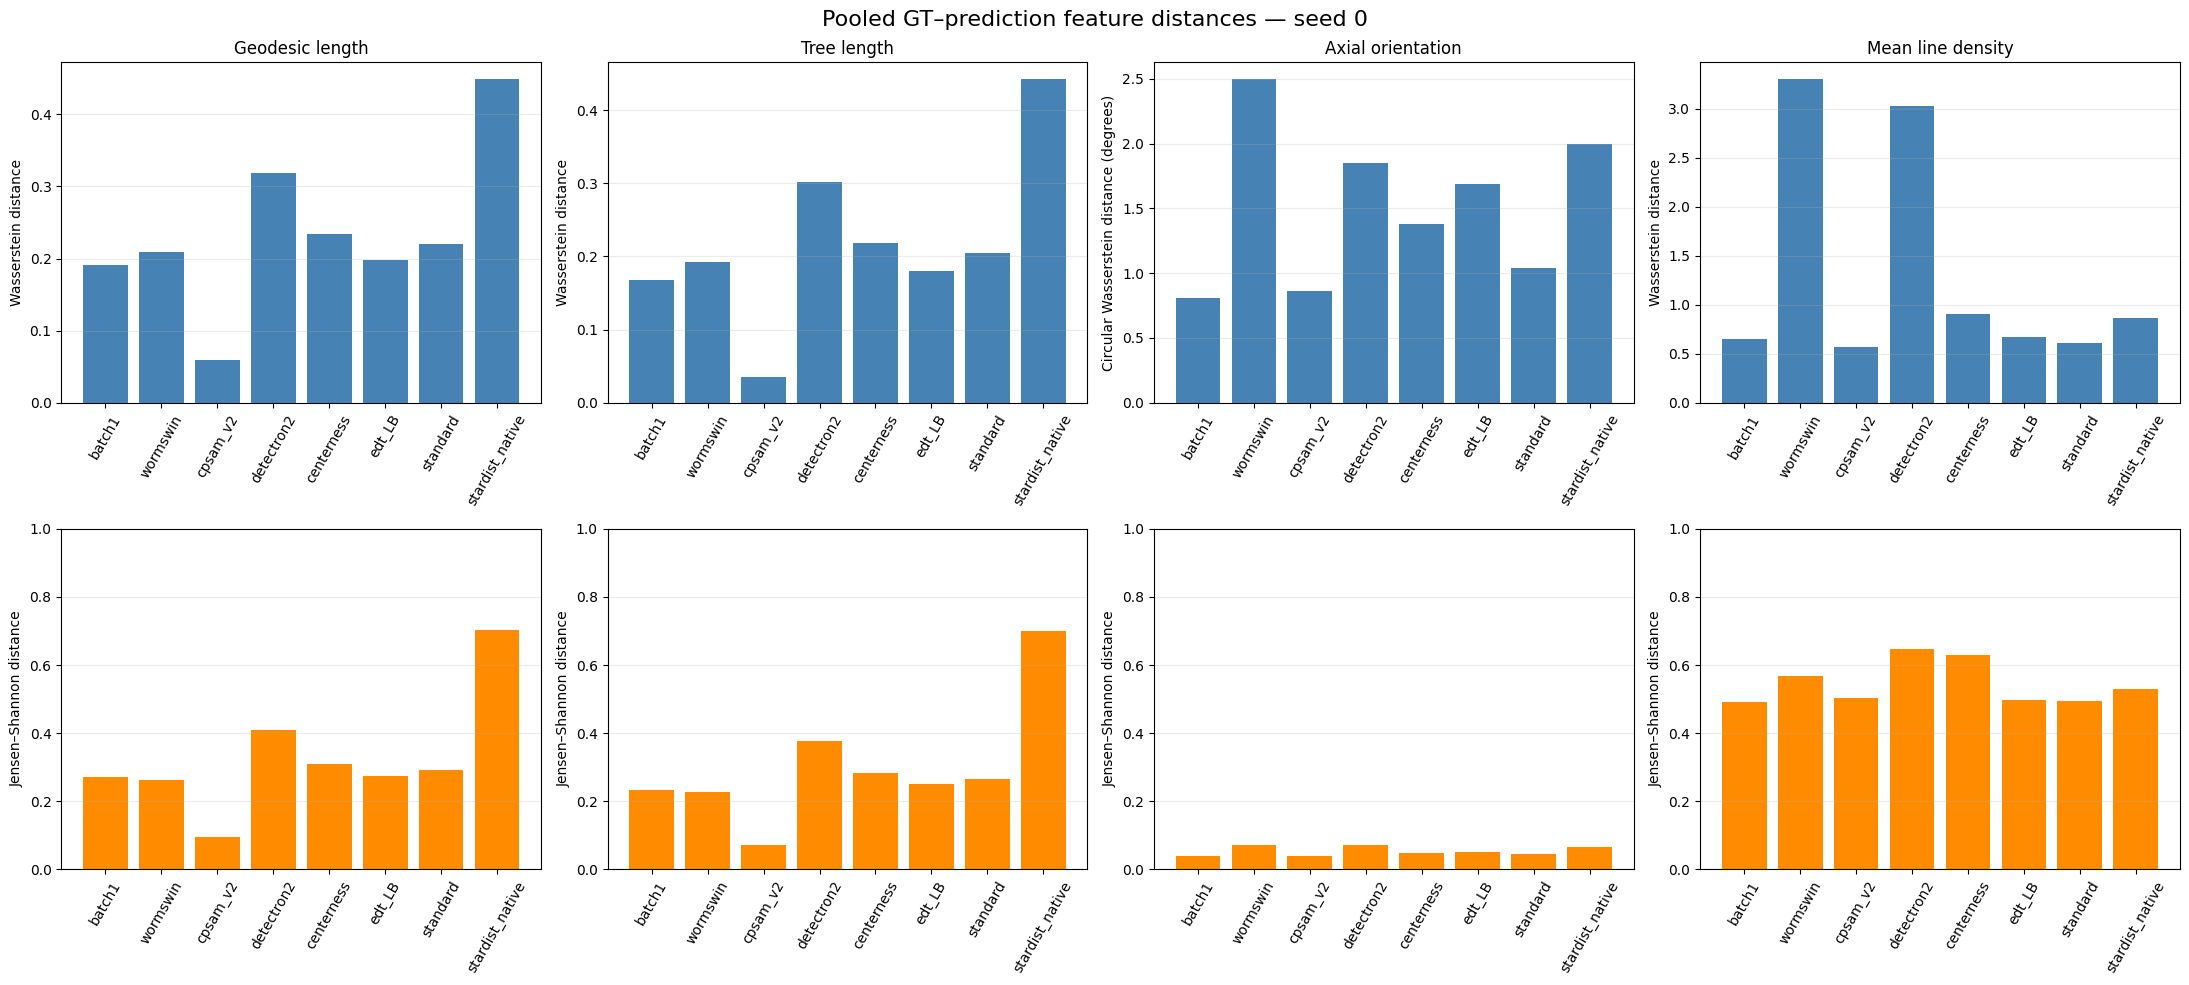

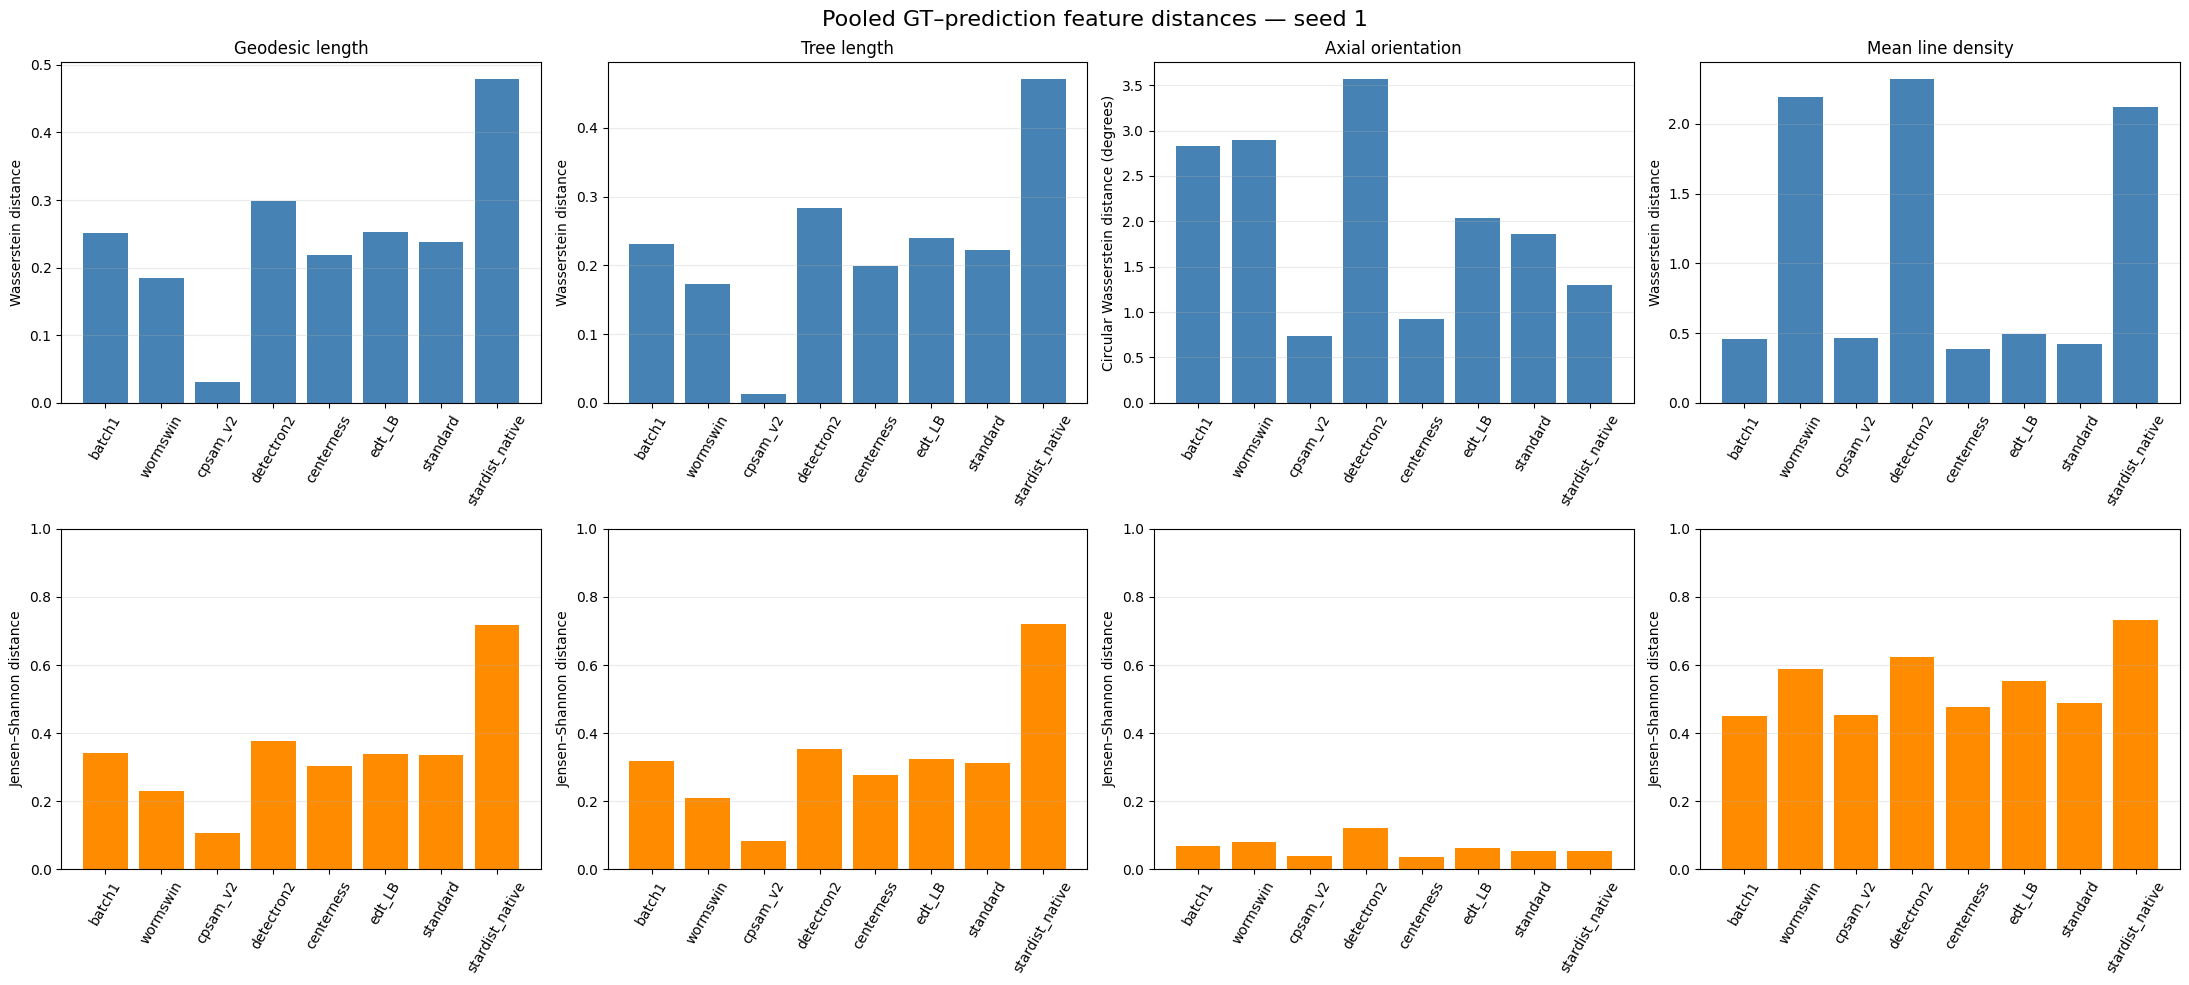

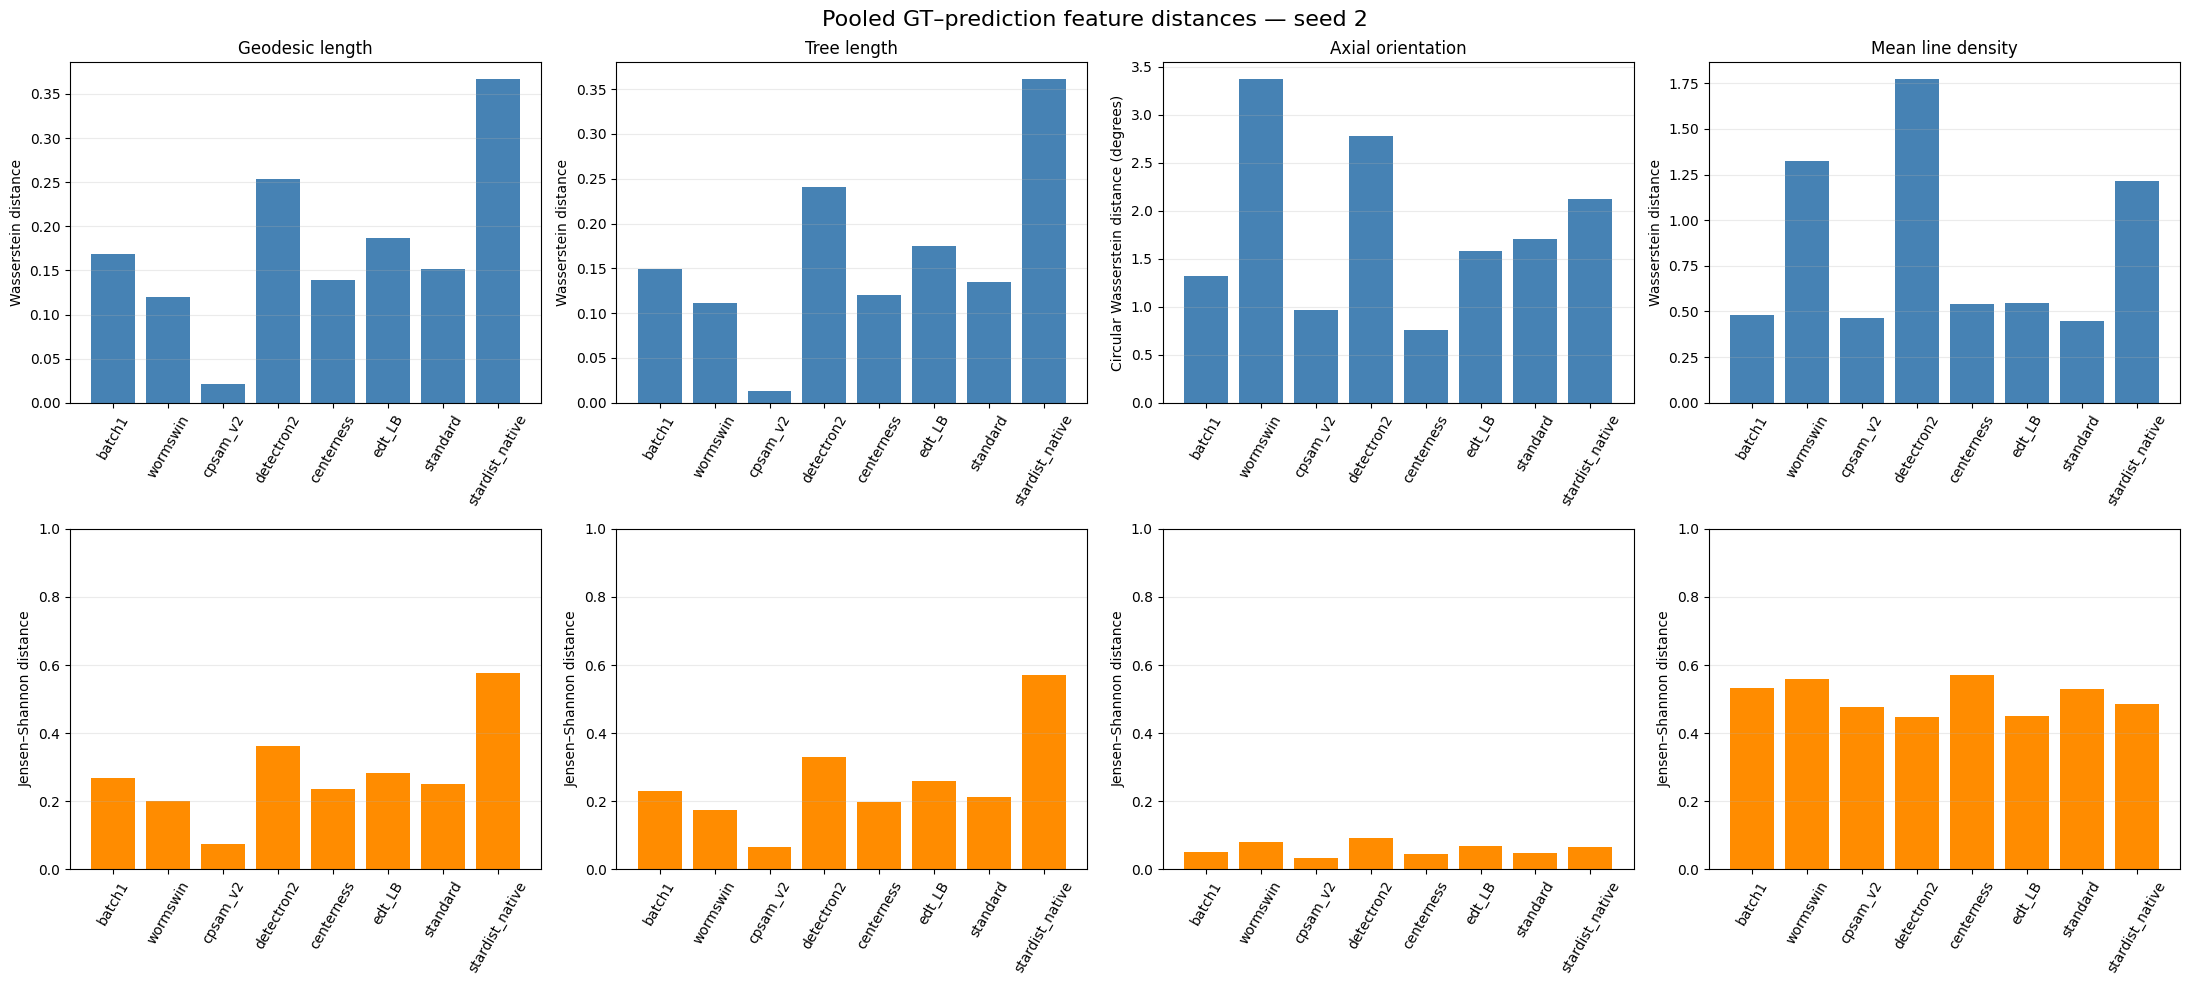

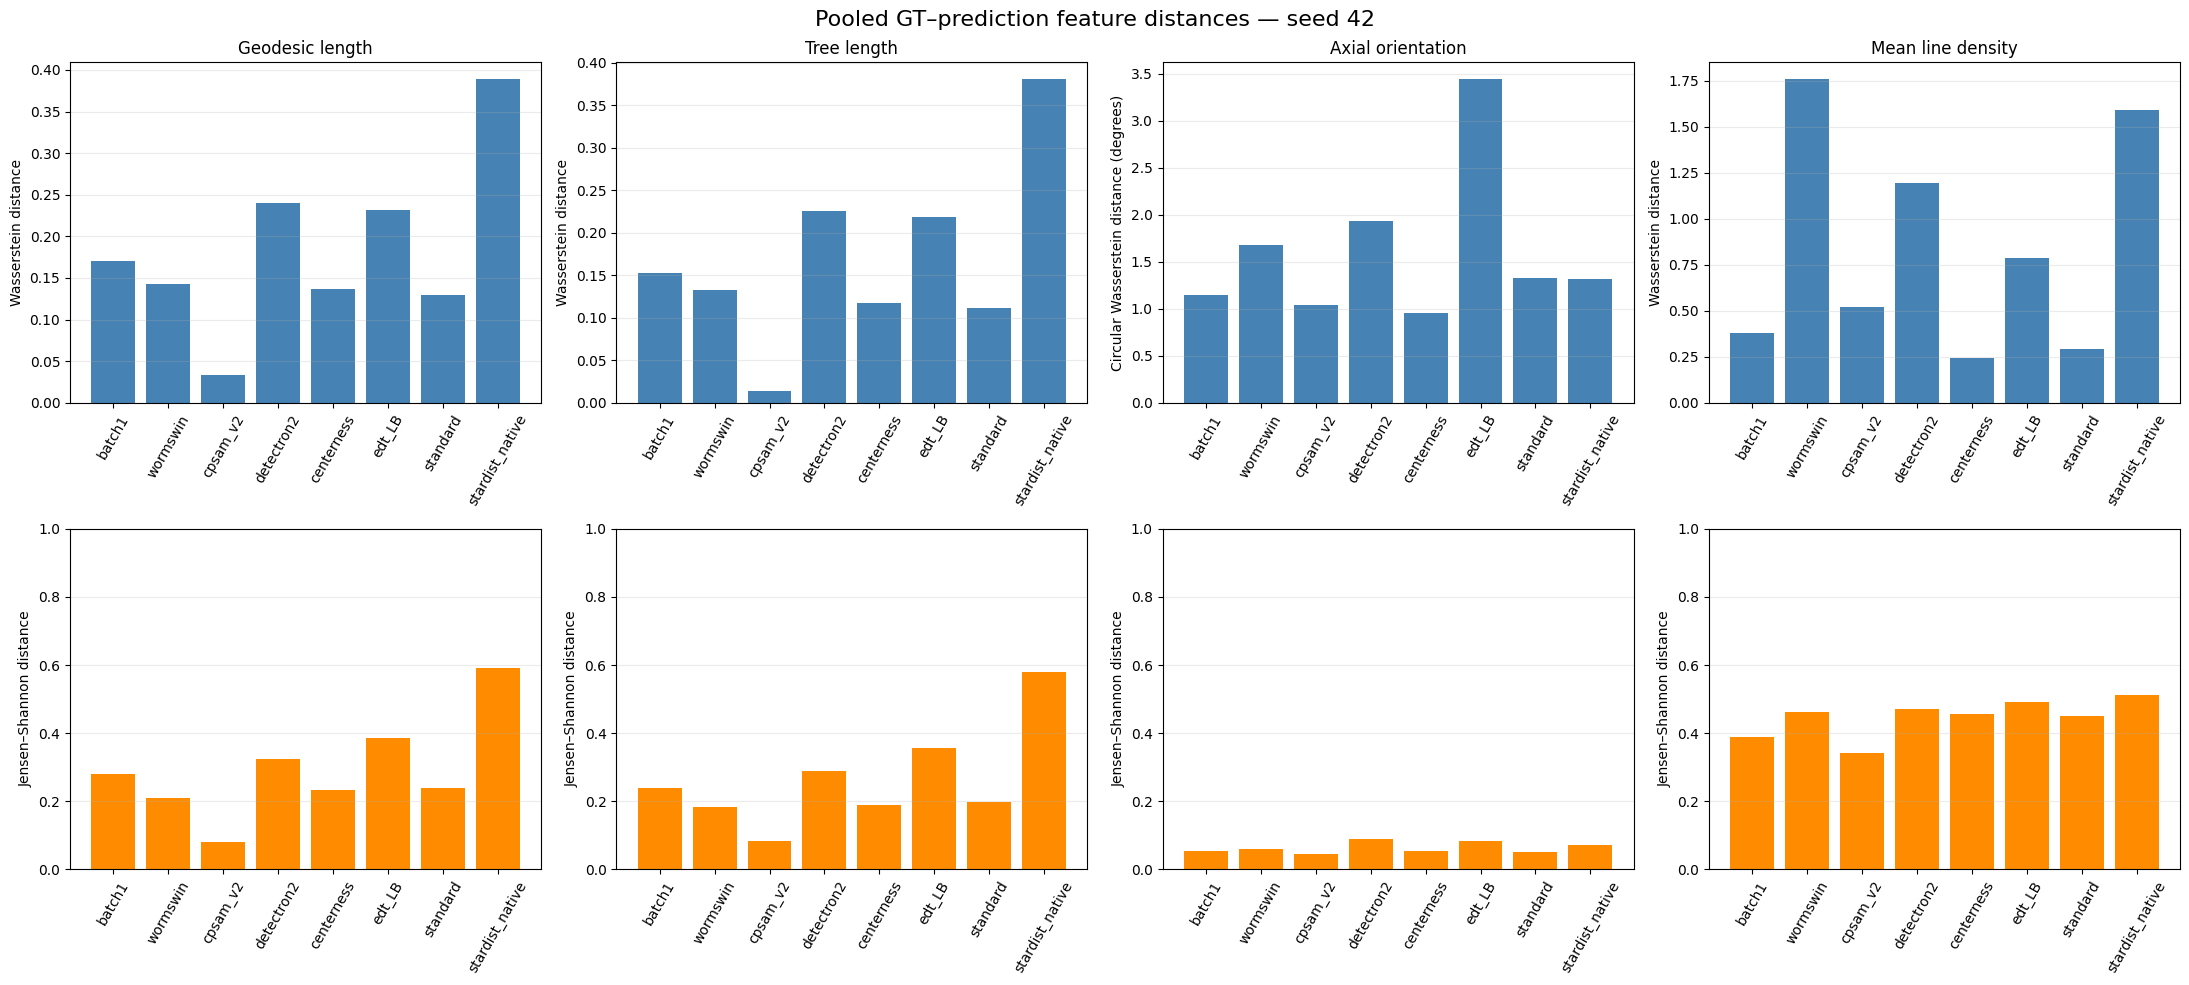

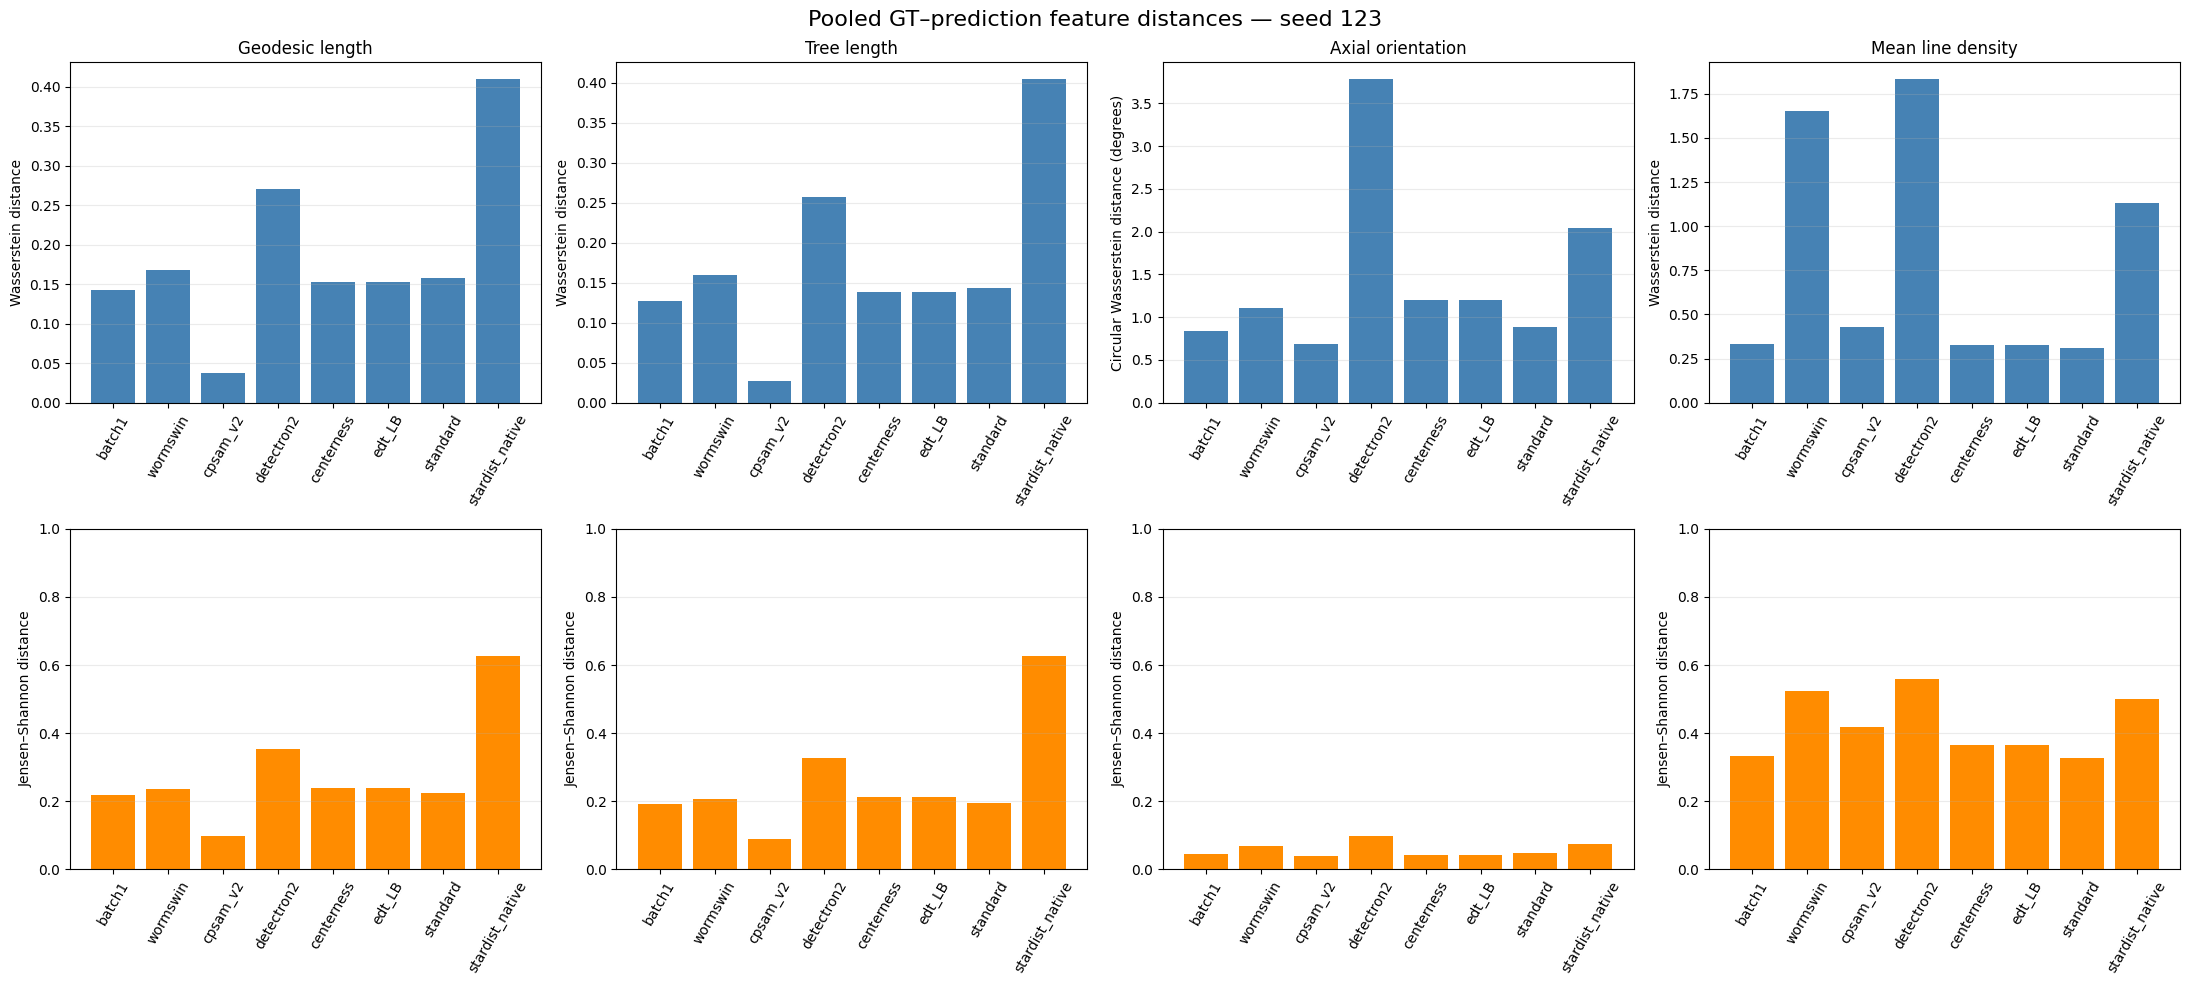

In [32]:
import matplotlib.pyplot as plt


FEATURE_LABELS = {
    "length_um": (
        "Geodesic length"
    ),
    "tree_length_um": (
        "Tree length"
    ),
    "orientation_angle": (
        "Axial orientation"
    ),
    "line_density_mean": (
        "Mean line density"
    ),
}


for seed in SEEDS:
    seed_results = (
        pooled_results_df.loc[
            pooled_results_df[
                "seed"
            ].eq(seed)
        ]
        .copy()
    )

    seed_results["family"] = (
        pd.Categorical(
            seed_results["family"],
            categories=FAMILY_ORDER,
            ordered=True,
        )
    )

    figure, axes = plt.subplots(
        2,
        4,
        figsize=(22, 10),
    )


    for column_index, feature in enumerate(
        FEATURE_ORDER
    ):
        feature_results = (
            seed_results.loc[
                seed_results[
                    "feature"
                ].eq(feature)
            ]
            .sort_values("family")
        )

        families = (
            feature_results[
                "family"
            ].astype(str)
        )


        axes[0, column_index].bar(
            families,
            feature_results[
                "wasserstein_distance"
            ],
            color="steelblue",
        )

        axes[0, column_index].set_title(
            FEATURE_LABELS[feature]
        )

        axes[0, column_index].set_ylabel(
            (
                "Circular Wasserstein "
                "distance (degrees)"
                if feature
                == "orientation_angle"
                else "Wasserstein distance"
            )
        )


        axes[1, column_index].bar(
            families,
            feature_results[
                "jensen_shannon_distance"
            ],
            color="darkorange",
        )

        axes[1, column_index].set_ylabel(
            "Jensen–Shannon distance"
        )

        axes[1, column_index].set_ylim(
            0,
            1,
        )


        for row_index in [
            0,
            1,
        ]:
            axes[
                row_index,
                column_index,
            ].tick_params(
                axis="x",
                rotation=60,
            )

            axes[
                row_index,
                column_index,
            ].grid(
                axis="y",
                alpha=0.25,
            )


    figure.suptitle(
        (
            "Pooled GT–prediction feature "
            f"distances — seed {seed}"
        ),
        fontsize=16,
    )

    figure.tight_layout()
    plt.show()

## Mean and 95% confidence interval across the five splits
For every baseline family and feature, calculate the mean
of the five pooled split-level Wasserstein and
Jensen–Shannon distances together with a 95% confidence
interval for that mean.
Because there are only five independent split-level values,
the confidence interval uses Student's t distribution:
    mean ± t_(0.975, n-1) * SD / sqrt(n)
with n = 5 and degrees of freedom = 4.

In [33]:
from scipy import stats


def mean_ci(
    values: pd.Series,
    confidence: float = 0.95,
) -> tuple[float, float, float]:
    """
    Calculate the arithmetic mean and a two-sided
    Student's t confidence interval.

    Returns
    -------
    mean : float
        Arithmetic mean.
    lower : float
        Lower confidence-interval bound.
    upper : float
        Upper confidence-interval bound.
    """
    values = pd.Series(
        values,
        dtype=float,
    ).dropna()

    count = len(values)

    if not count:
        return np.nan, np.nan, np.nan

    mean = values.mean()

    if count == 1:
        return mean, np.nan, np.nan

    half_width = (
        stats.sem(values)
        * stats.t.ppf(
            (1 + confidence) / 2,
            count - 1,
        )
    )

    return (
        mean,
        mean - half_width,
        mean + half_width,
    )


CONFIDENCE_LEVEL = 0.95

summary_rows = []


for (
    family,
    feature,
), group in pooled_results_df.groupby(
    [
        "family",
        "feature",
    ],
    sort=False,
):
    (
        mean_wasserstein,
        ci95_wasserstein_lower,
        ci95_wasserstein_upper,
    ) = mean_ci(
        group["wasserstein_distance"],
        confidence=CONFIDENCE_LEVEL,
    )

    (
        mean_jsd,
        ci95_jsd_lower,
        ci95_jsd_upper,
    ) = mean_ci(
        group["jensen_shannon_distance"],
        confidence=CONFIDENCE_LEVEL,
    )

    split_count = group[
        "seed"
    ].nunique()

    summary_rows.append(
        {
            "family": family,
            "feature": feature,
            "mean_wasserstein": (
                mean_wasserstein
            ),
            "ci95_wasserstein_lower": (
                ci95_wasserstein_lower
            ),
            "ci95_wasserstein_upper": (
                ci95_wasserstein_upper
            ),
            "ci95_wasserstein_half_width": (
                ci95_wasserstein_upper
                - mean_wasserstein
            ),
            "mean_jsd": mean_jsd,
            "ci95_jsd_lower": (
                ci95_jsd_lower
            ),
            "ci95_jsd_upper": (
                ci95_jsd_upper
            ),
            "ci95_jsd_half_width": (
                ci95_jsd_upper
                - mean_jsd
            ),
            "split_count": split_count,
        }
    )


family_feature_summary_df = pd.DataFrame(
    summary_rows
)


if len(family_feature_summary_df) != 32:
    raise RuntimeError(
        "Expected 8 families × 4 features "
        f"= 32 rows; found "
        f"{len(family_feature_summary_df)}."
    )


if not family_feature_summary_df[
    "split_count"
].eq(5).all():
    raise RuntimeError(
        "Some family/feature combinations "
        "do not contain all five split seeds."
    )


family_feature_summary_df["family"] = (
    pd.Categorical(
        family_feature_summary_df[
            "family"
        ],
        categories=FAMILY_ORDER,
        ordered=True,
    )
)

family_feature_summary_df["feature"] = (
    pd.Categorical(
        family_feature_summary_df[
            "feature"
        ],
        categories=FEATURE_ORDER,
        ordered=True,
    )
)


family_feature_summary_df = (
    family_feature_summary_df
    .sort_values(
        [
            "feature",
            "family",
        ]
    )
    .reset_index(drop=True)
)


display(
    family_feature_summary_df
)

,family,feature,mean_wasserstein,ci95_wasserstein_lower,ci95_wasserstein_upper,ci95_wasserstein_half_width,mean_jsd,ci95_jsd_lower,ci95_jsd_upper,ci95_jsd_half_width,split_count
0,batch1,length_um,0.184734,0.133880,0.235587,0.050853,0.276447,0.222040,0.330853,0.054407,5
1,wormswin,length_um,0.165202,0.121709,0.208695,0.043493,0.227255,0.197913,0.256597,0.029342,5
2,cpsam_v2,length_um,0.036165,0.018567,0.053763,0.017598,0.090383,0.073695,0.107071,0.016688,5
3,detectron2,length_um,0.276248,0.236191,0.316304,0.040056,0.364835,0.326305,0.403365,0.038530,5
4,centerness,length_um,0.176247,0.118477,0.234018,0.057771,0.264484,0.215468,0.313500,0.049016,5
5,edt_LB,length_um,0.204413,0.155689,0.253138,0.048724,0.304288,0.232971,0.375604,0.071317,5
6,standard,length_um,0.179522,0.120698,0.238346,0.058824,0.267875,0.211583,0.324167,0.056292,5
7,stardist_native,length_um,0.419420,0.363106,0.475733,0.056313,0.642835,0.563021,0.722648,0.079814,5
8,batch1,tree_length_um,0.165807,0.116629,0.214986,0.049179,0.242189,0.185798,0.298579,0.056390,5
9,wormswin,tree_length_um,0.153893,0.114329,0.193457,0.039564,0.199636,0.172559,0.226713,0.027077,5


In [34]:
family_feature_summary_table = (
    family_feature_summary_df
    .pivot(
        index="family",
        columns="feature",
        values=[
            "mean_wasserstein",
            "ci95_wasserstein_lower",
            "ci95_wasserstein_upper",
            "mean_jsd",
            "ci95_jsd_lower",
            "ci95_jsd_upper",
        ],
    )
)


family_feature_summary_table.columns = [
    f"{feature}__{statistic}"
    for statistic, feature
    in family_feature_summary_table.columns
]


family_feature_summary_table = (
    family_feature_summary_table
    .reindex(FAMILY_ORDER)
    .reset_index()
)


display(
    family_feature_summary_table
)

,family,length_um__mean_wasserstein,tree_length_um__mean_wasserstein,orientation_angle__mean_wasserstein,line_density_mean__mean_wasserstein,length_um__ci95_wasserstein_lower,tree_length_um__ci95_wasserstein_lower,orientation_angle__ci95_wasserstein_lower,line_density_mean__ci95_wasserstein_lower,length_um__ci95_wasserstein_upper,...,orientation_angle__mean_jsd,line_density_mean__mean_jsd,length_um__ci95_jsd_lower,tree_length_um__ci95_jsd_lower,orientation_angle__ci95_jsd_lower,line_density_mean__ci95_jsd_lower,length_um__ci95_jsd_upper,tree_length_um__ci95_jsd_upper,orientation_angle__ci95_jsd_upper,line_density_mean__ci95_jsd_upper
0,batch1,0.184734,0.165807,1.388567,0.460625,0.133880,0.116629,0.352213,0.308631,0.235587,...,0.051782,0.439787,0.222040,0.185798,0.038705,0.340727,0.330853,0.298579,0.064860,0.538846
1,wormswin,0.165202,0.153893,2.311658,2.048177,0.121709,0.114329,1.170214,1.092124,0.208695,...,0.071524,0.540915,0.197913,0.172559,0.060215,0.478421,0.256597,0.226713,0.082834,0.603409
2,cpsam_v2,0.036165,0.020286,0.858445,0.491198,0.018567,0.007460,0.674214,0.420619,0.053763,...,0.039415,0.439058,0.073695,0.066562,0.034744,0.361111,0.107071,0.090184,0.044086,0.517006
3,detectron2,0.276248,0.261802,2.785869,2.032891,0.236191,0.223165,1.669063,1.180044,0.316304,...,0.094277,0.550028,0.326305,0.293764,0.072428,0.440232,0.403365,0.376370,0.116126,0.659823
4,centerness,0.176247,0.158484,1.041719,0.479844,0.118477,0.100034,0.736536,0.152727,0.234018,...,0.045368,0.500366,0.215468,0.175512,0.036925,0.371848,0.313500,0.287553,0.053812,0.628885
5,edt_LB,0.204413,0.190473,1.990228,0.565469,0.155689,0.141249,0.911525,0.346760,0.253138,...,0.061421,0.471201,0.232971,0.207375,0.042073,0.384434,0.375604,0.353167,0.080769,0.557967
6,standard,0.179522,0.163383,1.363197,0.415990,0.120698,0.104583,0.843270,0.260374,0.238346,...,0.049115,0.458037,0.211583,0.172152,0.045362,0.360123,0.324167,0.301053,0.052868,0.555951
7,stardist_native,0.419420,0.412630,1.757048,1.384297,0.363106,0.356947,1.244556,0.778001,0.475733,...,0.066180,0.552346,0.563021,0.553951,0.056357,0.426181,0.722648,0.724146,0.076004,0.678511


## Cross-split feature comparison for all baseline models

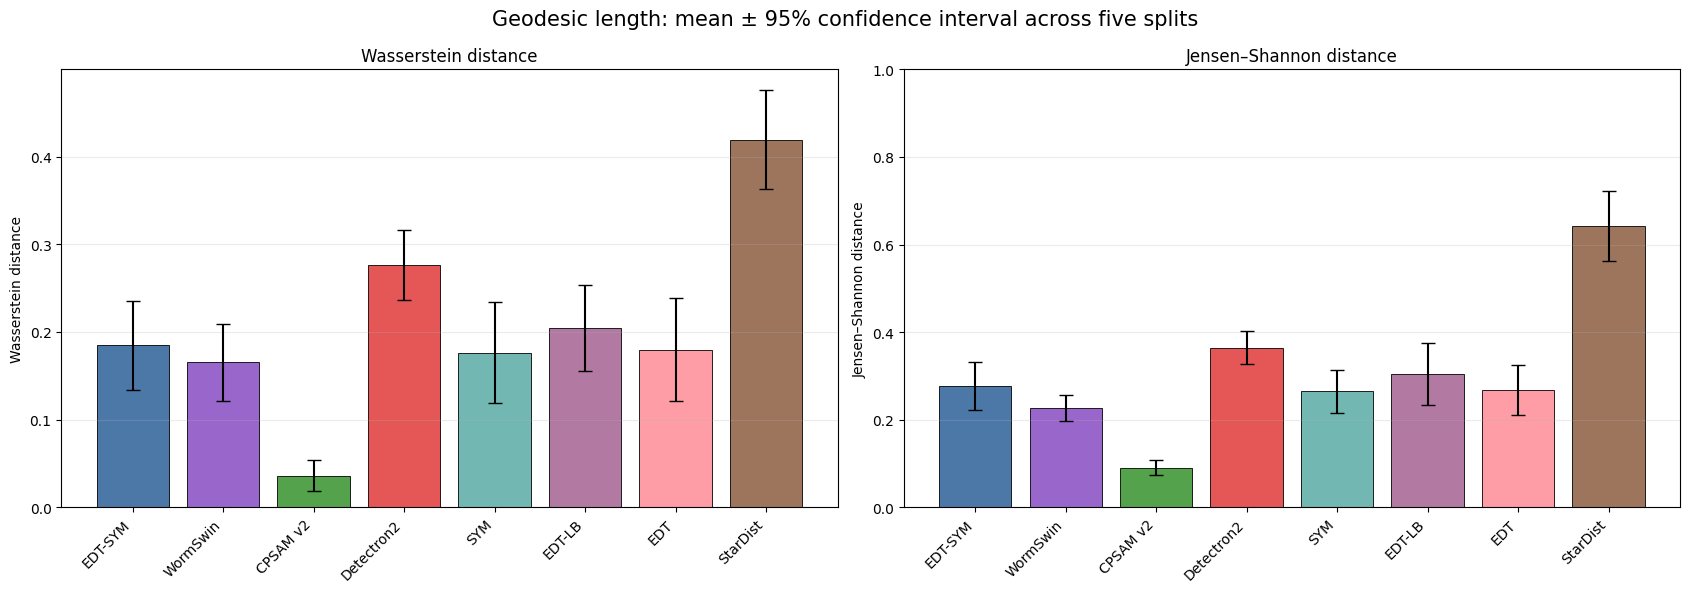

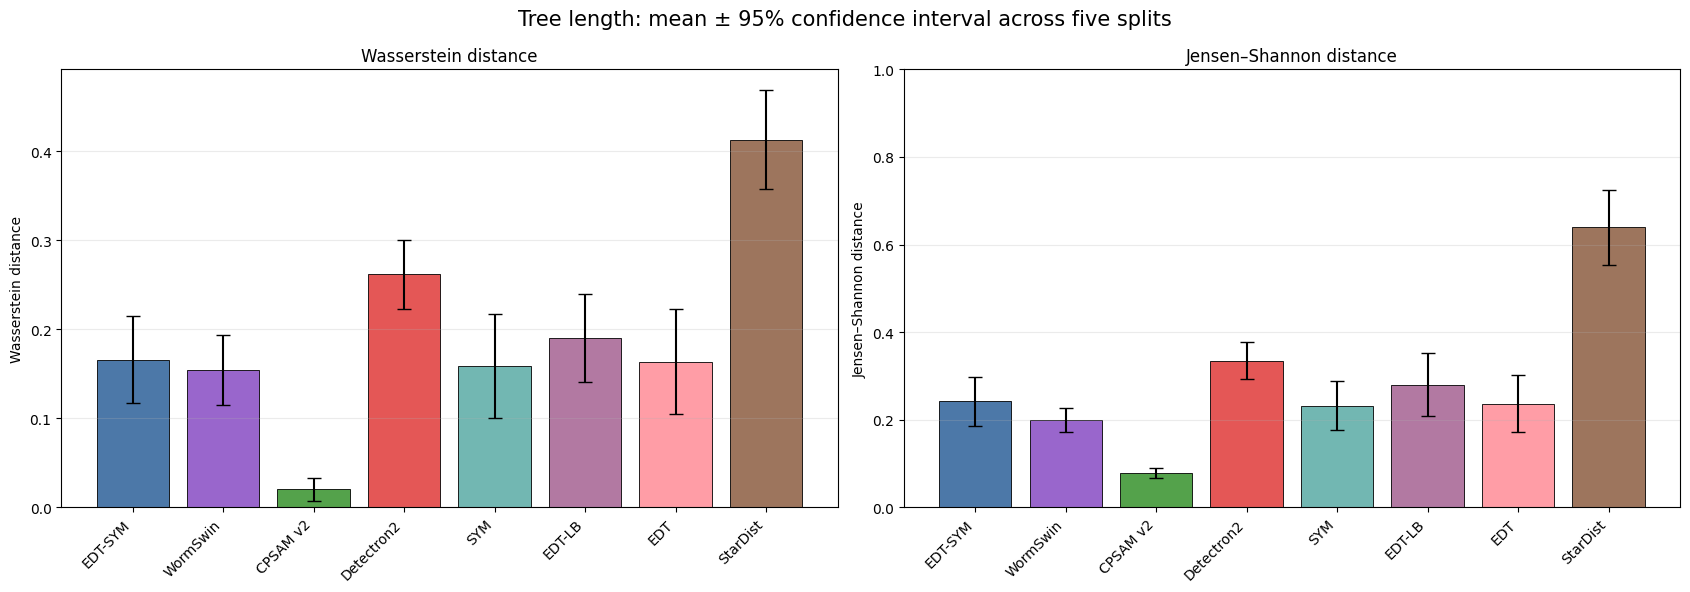

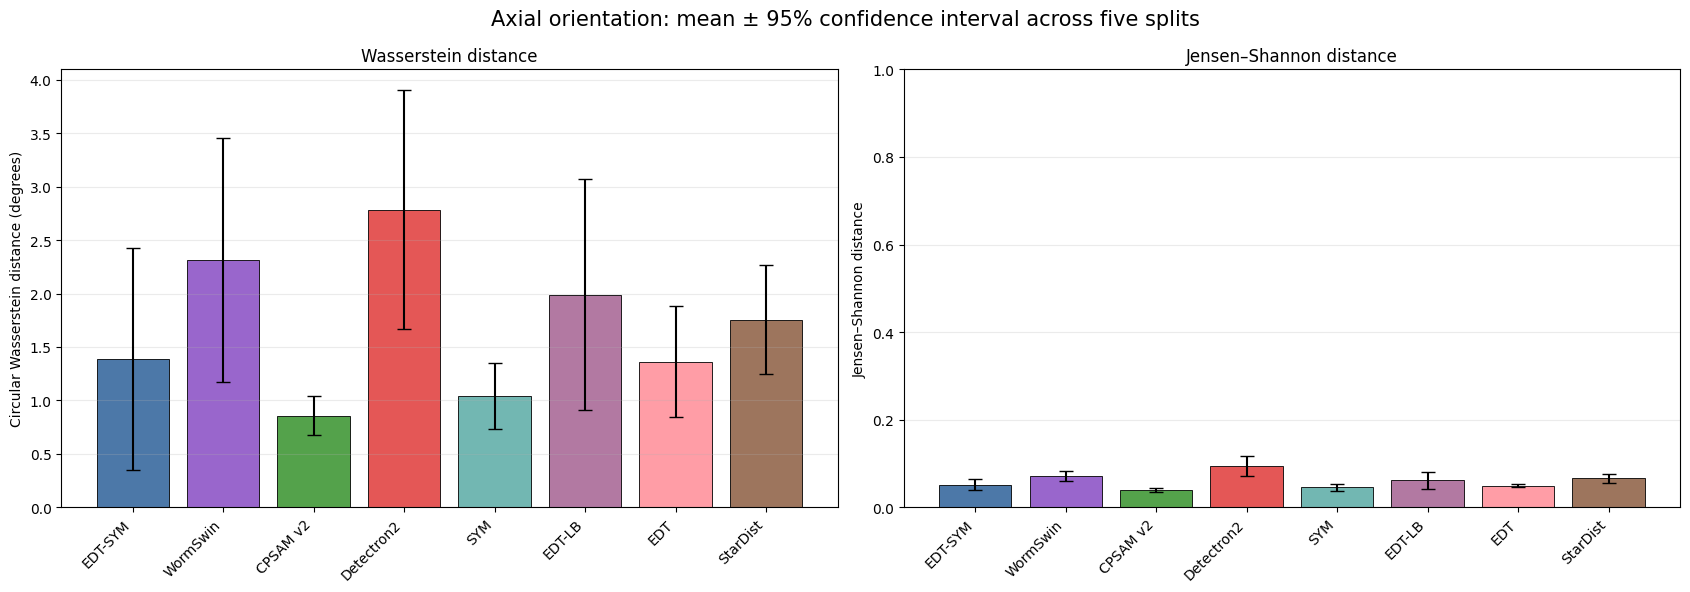

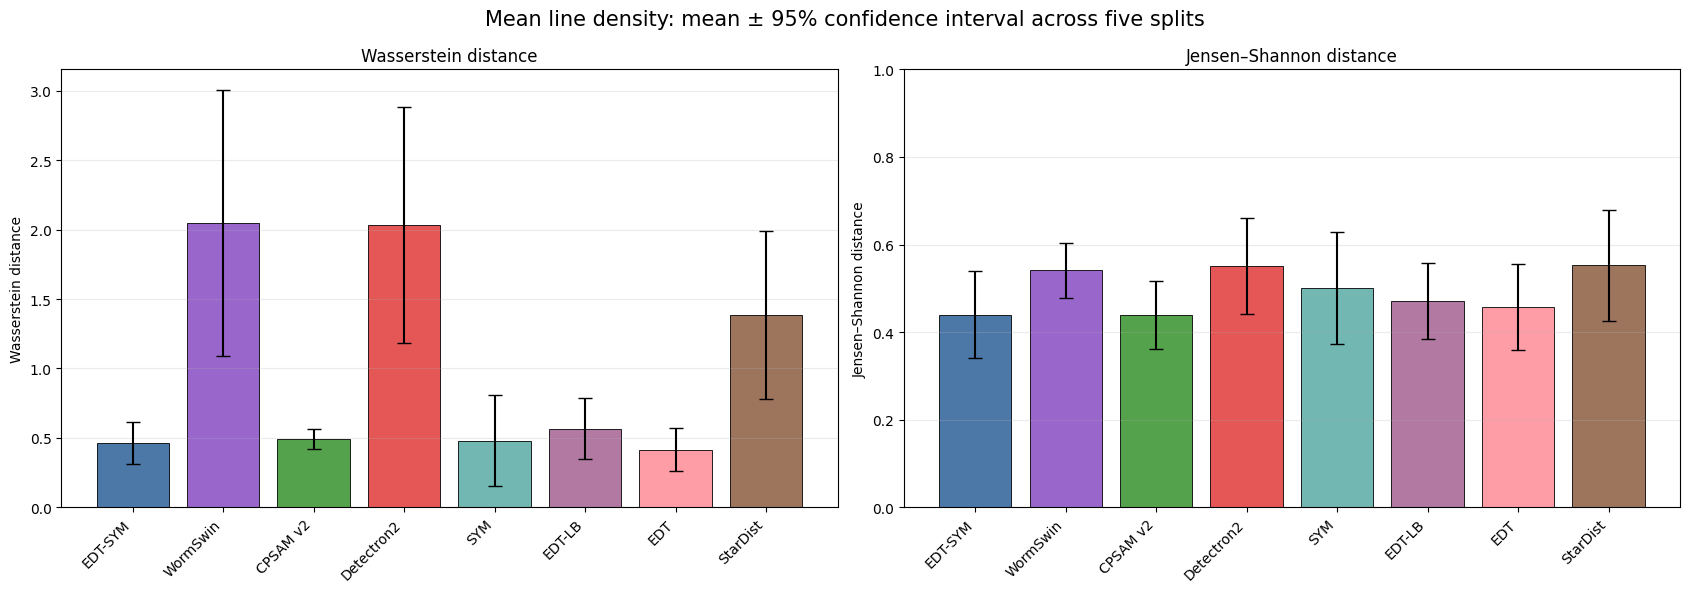

In [35]:
# %%
MODEL_LABELS = {
    "batch1": "EDT-SYM",
    "wormswin": "WormSwin",
    "cpsam_v2": "CPSAM v2",
    "detectron2": "Detectron2",
    "centerness": "SYM",
    "edt_LB": "EDT-LB",
    "standard": "EDT",
    "stardist_native": "StarDist",
}

MODEL_COLORS = [
    "#4C78A8",
    "#9966cc",
    "#54A24B",
    "#E45756",
    "#72B7B2",
    "#B279A2",
    "#FF9DA6",
    "#9D755D",
]


for feature in FEATURE_ORDER:
    feature_summary = (
        family_feature_summary_df.loc[
            family_feature_summary_df[
                "feature"
            ].eq(feature)
        ]
        .set_index("family")
        .reindex(FAMILY_ORDER)
        .reset_index()
    )

    model_labels = [
        MODEL_LABELS[family]
        for family in FAMILY_ORDER
    ]

    x_positions = np.arange(
        len(FAMILY_ORDER)
    )


    figure, axes = plt.subplots(
        1,
        2,
        figsize=(17, 6),
    )


    axes[0].bar(
        x_positions,
        feature_summary[
            "mean_wasserstein"
        ],
        yerr=feature_summary[
            "ci95_wasserstein_half_width"
        ],
        capsize=5,
        color=MODEL_COLORS,
        edgecolor="black",
        linewidth=0.6,
    )

    axes[0].set_title(
        "Wasserstein distance"
    )

    axes[0].set_ylabel(
        (
            "Circular Wasserstein "
            "distance (degrees)"
            if feature
            == "orientation_angle"
            else "Wasserstein distance"
        )
    )


    axes[1].bar(
        x_positions,
        feature_summary[
            "mean_jsd"
        ],
        yerr=feature_summary[
            "ci95_jsd_half_width"
        ],
        capsize=5,
        color=MODEL_COLORS,
        edgecolor="black",
        linewidth=0.6,
    )

    axes[1].set_title(
        "Jensen–Shannon distance"
    )

    axes[1].set_ylabel(
        "Jensen–Shannon distance"
    )

    axes[1].set_ylim(
        0,
        1,
    )


    for axis in axes:
        axis.set_xticks(
            x_positions
        )

        axis.set_xticklabels(
            model_labels,
            rotation=45,
            ha="right",
        )

        axis.grid(
            axis="y",
            alpha=0.25,
        )


    figure.suptitle(
        (
            f"{FEATURE_LABELS[feature]}: "
            "mean ± 95% confidence interval "
            "across five splits"
        ),
        fontsize=15,
    )

    figure.tight_layout()
    plt.show()

## Save distribution-comparison results

In [36]:
import json


RESULTS_DIR = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "wasserstein_jsd_feature_comparison"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


outputs = {
    "pooled_distribution_distances.csv": (
        pooled_results_df
    ),
    "family_summary_across_seeds.csv": (
        family_feature_summary_df
    ),
    "per_image_linear_distances.csv": (
        per_image_linear_results_df
    ),
    "per_image_orientation_distances.csv": (
        per_image_orientation_results_df
    ),
    "per_image_linear_summary.csv": (
        per_image_linear_summary_df
    ),
    "per_image_orientation_summary.csv": (
        per_image_orientation_summary_df
    ),
    "prediction_coverage.csv": (
        prediction_coverage_df
    ),
    "feature_validity_checks.csv": (
        validity_df
    ),
    "undefined_orientation_objects.csv": (
        undefined_orientation_df
    ),
    "global_linear_histogram_bins.csv": (
        global_bin_summary_df
    ),
    "run_manifest.csv": (
        run_manifest_df
    ),
}


saved_paths = []

for filename, table in outputs.items():
    output_path = (
        RESULTS_DIR
        / filename
    )

    table.to_csv(
        output_path,
        index=False,
    )

    saved_paths.append(
        output_path
    )


analysis_metadata = {
    "description": (
        "GT-versus-prediction feature-distribution "
        "comparison using Wasserstein and "
        "Jensen-Shannon distances."
    ),
    "families": sorted(
        run_manifest_df[
            "family"
        ].unique().tolist()
    ),
    "seeds": sorted(
        int(seed)
        for seed in run_manifest_df[
            "seed"
        ].unique()
    ),
    "features": [
        "length_um",
        "tree_length_um",
        "orientation_angle",
        "line_density_mean",
    ],
    "linear_histogram_bin_count": int(
        JSD_BINS
    ),
    "jensen_shannon_base": int(
        JSD_BASE
    ),
    "linear_histogram_bins": (
        "One global shared set of bin edges "
        "per feature across all GT and "
        "prediction datasets."
    ),
    "orientation_is_axial": True,
    "orientation_period_deg": float(
        ORIENTATION_PERIOD_DEG
    ),
    "orientation_bin_count": int(
        ORIENTATION_BIN_COUNT
    ),
    "orientation_bin_width_deg": float(
        ORIENTATION_BIN_WIDTH_DEG
    ),
    "orientation_smoothing_sigma_bins": float(
        ORIENTATION_SMOOTHING_SIGMA_BINS
    ),
    "nonfinite_value_handling": (
        "Objects with nonfinite feature values "
        "were excluded. The excluded undefined "
        "orientations were visually confirmed "
        "as degenerate one-pixel or disconnected "
        "pixel objects."
    ),
    "empty_prediction_handling": (
        "Per-image distances are NaN when a model "
        "has no predictions for that image. "
        "Coverage is reported separately and no "
        "arbitrary distance penalty is assigned."
    ),
    "pooled_interpretation": (
        "Pooled distances compare complete GT "
        "and prediction marginal distributions "
        "within each seed; they do not use "
        "object-level correspondence."
    ),
}


metadata_path = (
    RESULTS_DIR
    / "analysis_metadata.json"
)

metadata_path.write_text(
    json.dumps(
        analysis_metadata,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

saved_paths.append(
    metadata_path
)


required_row_counts = {
    "pooled_distribution_distances.csv": 160,
    "family_summary_across_seeds.csv": 32,
    "per_image_linear_distances.csv": 2400,
    "per_image_orientation_distances.csv": 1200,
    "prediction_coverage.csv": 40,
    "undefined_orientation_objects.csv": 15,
    "run_manifest.csv": 40,
}


for filename, expected_rows in (
    required_row_counts.items()
):
    actual_rows = len(
        outputs[filename]
    )

    if actual_rows != expected_rows:
        raise RuntimeError(
            f"{filename}: expected "
            f"{expected_rows} rows; found "
            f"{actual_rows}."
        )


print(
    "Results directory:",
    RESULTS_DIR,
)

print()
print("Saved files:")

for path in saved_paths:
    print(
        f"  {path.name}"
    )

print()
print(
    "PASS: distribution-comparison "
    "results saved successfully."
)

Results directory: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\wasserstein_jsd_feature_comparison

Saved files:
  pooled_distribution_distances.csv
  family_summary_across_seeds.csv
  per_image_linear_distances.csv
  per_image_orientation_distances.csv
  per_image_linear_summary.csv
  per_image_orientation_summary.csv
  prediction_coverage.csv
  feature_validity_checks.csv
  undefined_orientation_objects.csv
  global_linear_histogram_bins.csv
  run_manifest.csv
  analysis_metadata.json

PASS: distribution-comparison results saved successfully.
